TODO
- 

- acoustic_edge_onsets with permutation,,, try to load sub-DM1027_ses-intraop_task-lombard_run-05_acousticspectrum-formant.mat as a fieldtrip object
- notch filter at 30 Hz? see 
- remove all dbs channels from current pipeline? we don't have any Lombard DBS patients of interest [though there are some later subjects with ET-VIM lombard data]
- save raw_beta() and raw_thetaalpha() traces in addition to raw_gamma()
- implement Lucia's beta burst pipeline, turn them into traces

- add filter to remove trials that have sentence onset before audio offset

- for sentence specificity: consider baselining data for normalization rather than subtracting mean

- consider increasing the width of notch filters--we see residual line noise artifact, eg DM1013
- consider different gamma extraction pipelines for ecog and subcort

- run ANOVAs gamma ~ {NOISE, QUIET} + {SPEECH, BASELINE}


batch process 2025 08 01
- DM1019 r4 ValueError: No appropriate channels found for the given picks ([])
- DM1021 r4 behavioral channels missing
- DM1014 r3 (no ecog) ValueError: No appropriate channels found for the given picks ([])
- DM1009 r1 and r2 ValueError: Channel type "dbs" is not present in the Raw file
- DM1038 check artifact trial_id, also appears that there are no subctx recordings? 
- DM1023 gamma traces are flat in A02_01_single-channel-warped-gamma-sentencewise

figure out with DM1005, DM1021 have macro_Lm channels that are all nans--due to filtering?


# Setup

In [1]:
# Run until error around 9
# Jump to 15.

# subject_id="DM1002"
# run_id=4

# subject_id="DM1003"
# run_id=4

# subject_id="DM1005"
# run_id=2

# subject_id="DM1006"
# run_id=2

# subject_id="DM1007"
# run_id=1

# subject_id = "DM1008"
# run_id=1

# subject_id="DM1009"
# run_id=1

# subject_id="DM1012"
# run_id=2

# subject_id="DM1021"
# run_id=4

# subject_id="DM1022"
# run_id=3

# subject_id="DM1023"
# run_id=3

# subject_id="DM1022"
# run_id=3

# subject_id = "DM1024"
# run_id=2

subject_id="DM1025"
run_id=1

# subject_id="DM1028"
# run_id=5

# subject_id="DM1029"
# run_id=3

# subject_id="DM1033"
# run_id=3

# subject_id="DM1035"
# run_id=1

# subject_id="DM1037"
# run_id=1

# subject_id="DM1038"
# run_id=2

# subject_id="DM1039"
# run_id=3


base_path="Y:/DBS/derivatives"
base_path = "/Volumes/Nexus4/DBS/derivatives"
OVERRIDE_FLAG = False


In [2]:
# p = Path('Y:/DBS/groupanalyses/task-lombard/20230602-metadata-and-groupdata-PLB/subjects-all-runs_manual_ecog_PLB20250725.xlsx')
# runs_meta_df = pd.read_excel(p)
# runs_meta_df = runs_meta_df[['run', 'subject']]
# # runs_meta.run = runs_meta.run.astype(int)
# # runs_meta

# runs_meta_df = runs_meta_df[runs_meta_df.subject=="DM1039"]
# runs_meta_df

In [3]:
import mne
import numpy as np
import pandas as pd
import datetime
from scipy.io import loadmat
from pathlib import Path
# import hdf5storage as h5

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('ggplot')


import h5py
import seaborn as sns
# from plotnine import *
import plotnine as p9
from scipy.stats import ranksums, ttest_ind
import re
import scipy

import shutil

from copy import deepcopy
import random 
import pickle

import sklearn


In [4]:
# if using raw.plot() calls
# %matplotlib qt

In [5]:
base_path = Path(base_path)
subj_path = base_path / f"sub-{subject_id}"

GTC_START = datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc)


# these are used for warping trials later 
p = r'/Volumes/Nexus4/DBS/groupanalyses/task-lombard/20220922-behavior-overview-PLB/data/B03_01_word-onset-by-sentences_sub-all-DM1001-39.tsv'
WORDS_PER_TRIAL = pd.read_csv(p, sep='\t')
WORDS_PER_TRIAL = WORDS_PER_TRIAL.query(f'subject_id == "{subject_id}" and run_id=={run_id}')

p = r'/Volumes/Nexus4/DBS/groupanalyses/task-lombard/20220922-behavior-overview-PLB/data/B03_03_word-onset-by-sentences-summarized-per-sentid_sub-all-DM1001-39_manual.tsv'
COHORT_WORD_ONSET_PER_SENTID = pd.read_csv(p, sep='\t')


WORDS_PER_TRIAL = WORDS_PER_TRIAL.merge(COHORT_WORD_ONSET_PER_SENTID, how='left', on=['sentence_id'], suffixes=('', '_warpto'))

# WORDS_PER_TRIAL
# COHORT_WORD_ONSET_PER_SENTID
# 'T_pc1','T_pc2','T_pc3','T_pc4'	,'T_pc5','T_pc6','J_pc1','J_pc2','L_pc1','L_pc2','L_pc3','L_pc4'

# ELECTRODES = pd.read_csv(subj_path / "annot" / f"sub-{subject_id}_electrodes.tsv", sep='\t')
# ELECTRODES = pd.read_csv("Y:/DBS/groupanalyses/task-lombard/20230328-subctx-ctx-group-coverage-PLB/A02b_electrodes-all-subj-DM1001-DM1039-with-lombard-run-id.tsv", sep='\t')
ELECTRODES = pd.read_csv("/Volumes/Nexus4/DBS/groupanalyses/task-lombard/20230328-subctx-ctx-group-coverage-PLB/A02b_electrodes-all-subj-DM1001-DM1039-with-lombard-run-id.tsv", sep='\t')
ELECTRODES = ELECTRODES[(ELECTRODES.subject_id==subject_id) & (ELECTRODES.lombard_run_id==run_id)]
ELECTRODES

# hcpmap = pd.read_csv("Z:/Resources/HCPMMP1-Labeling-Atlas/HCPMMP1-labels2areas.tsv", sep='\t')
# ELECTRODES = ELECTRODES.merge(hcpmap, how='left', left_on='HCPMMP1_label_1', right_on='label')
# ELECTRODES = ELECTRODES.merge(hcpmap, how='left', left_on='HCPMMP1_label_2', right_on='label', suffixes=['', '_2'])
# ELECTRODES


,subject_id,path_annot,exists_annot,onset,duration,lombard_run_id,name,type,native_x,native_y,...,DISTAL_label_1,DISTAL_weight_1,DISTAL_label_2,DISTAL_weight_2,DISTAL_label_3,DISTAL_weight_3,HCPMMP1_label_1,HCPMMP1_weight_1,HCPMMP1_label_2,HCPMMP1_weight_2
3772,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,dbs_L1,DBS,-13.042478,-18.396912,...,094_Thalamus_ventro_intermedius_externus_Vime_L,0.475934,088_Thalamus_ventro_oralis_posterior_Vop_L,0.263265,024_Reticulatus_polaris_L,0.140818,NaN,NaN,NaN,NaN
3773,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,dbs_L2A,DBS,-14.138930,-17.007976,...,088_Thalamus_ventro_oralis_posterior_Vop_L,0.684507,094_Thalamus_ventro_intermedius_externus_Vime_L,0.170319,024_Reticulatus_polaris_L,0.084683,NaN,NaN,NaN,NaN
3774,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,dbs_L2B,DBS,-14.609714,-18.008622,...,094_Thalamus_ventro_intermedius_externus_Vime_L,0.490391,088_Thalamus_ventro_oralis_posterior_Vop_L,0.422336,024_Reticulatus_polaris_L,0.056535,NaN,NaN,NaN,NaN
3775,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,dbs_L2C,DBS,-13.668146,-17.704906,...,094_Thalamus_ventro_intermedius_externus_Vime_L,0.569385,088_Thalamus_ventro_oralis_posterior_Vop_L,0.395394,091_Thalamus_ventro_intermedius_internus_Vimi_L,0.020940,NaN,NaN,NaN,NaN
3776,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,dbs_L3A,DBS,-15.235383,-16.184898,...,088_Thalamus_ventro_oralis_posterior_Vop_L,0.760161,024_Reticulatus_polaris_L,0.124033,094_Thalamus_ventro_intermedius_externus_Vime_L,0.074235,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3901,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,ecog_L259,ECOG,-58.944840,5.025831,...,NaN,NaN,NaN,NaN,NaN,NaN,6v,0.890212,6r,5.505719e-07
3902,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,ecog_L260,ECOG,-57.965238,6.081339,...,NaN,NaN,NaN,NaN,NaN,NaN,6v,0.935484,6r,1.930061e-09
3903,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,ecog_L261,ECOG,-57.969106,7.101106,...,NaN,NaN,NaN,NaN,NaN,NaN,6v,0.862598,6r,3.500972e-10
3904,DM1025,/Volumes/Nexus4/DBS/groupanalyses/task-lombard...,True,70466.05499,662.486912,1,ecog_L262,ECOG,-56.981260,8.136639,...,NaN,NaN,NaN,NaN,NaN,NaN,6v,0.776950,6r,1.172407e-05


In [6]:
# ECOG_SPATIAL_ORDER = 
idxs_first = np.arange(1, 21+1) 
idxs_middle = np.arange(22, 42+1) 
idxs_third = np.arange(43, 63+1) 
idxs = np.array([idxs_first, idxs_middle, idxs_third]).T.ravel()
ECOG_SPATIAL_ORDER = [f'ecog_L1{i:02d}' for i in idxs] + [f'ecog_L2{i:02d}' for i in idxs]

# Load fieldtrip

In [7]:

# def bml_load_raw_lombard_run(subject_id, run_id, base_path, meas_date=datetime(2000, 1, 1)):
TASK = 'smsl'

"""
Load raw data, channel types, artifact annotations, and trial events
for a Lombard task run from FieldTrip-formatted .mat data.

Parameters
----------
subject_id : str
    Subject identifier (e.g., "DM1033").
run_id : str or int
    Run number (e.g., "03" or 3).
base_path : str or Path
    Root path to DBS/derivatives directory.
meas_date : datetime
    Arbitrary reference date for aligning annotations (default: Jan 1, 2000).

Returns
-------
raw : mne.io.RawArray
    Raw data with annotations attached.
events : pd.DataFrame
    Trial event information (from trials.tsv).
"""

# mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"
# mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-{TASK}_run-{run_id:02d}_ft-raw.mat"
mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-{TASK}_ft-raw.mat"


# --- Step 1: Load first sample time from FieldTrip object using h5py
with h5py.File(mat_path, 'r') as f:
    time_array = f['D']['time'][0][0]  # Access time vector
    time_vec = f[time_array][()]  # Dereference
    GTC_RUN_ONSET = time_vec[0][0]  # first time point in seconds
    GTC_RUN_OFFSET = time_vec[-1][0]
    meas_date = datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc) + datetime.timedelta(seconds=GTC_RUN_ONSET)


# raw = mne.io.read_raw_fieldtrip("Y:/DBS/derivatives/sub-DM1033/fieldtrip/sub-DM1033_ses-intraop_task-lombard_run-03_ft-raw-test-small-withaudio.mat", None, data_name='D')
raw = mne.io.read_raw_fieldtrip(mat_path, None, data_name='D')
# raw = scipy.io.loadmat(mat_path)
raw.set_meas_date(meas_date)
bml2fiff = {'ECOG': 'ecog', 
            'AUDIO': 'stim', 
            'SEEG': 'dbs', 
            'DBS': 'dbs', 
            'MACRO': 'dbs',
            'MICRO': 'misc',
            'OTHER': 'misc', 
            'MISC': 'misc', 
            'PD': 'misc', 
            }
mnetype2fiff = mne.io.get_channel_type_constants(include_defaults=False)

chan_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_channels.tsv"
chan_df = pd.read_csv(chan_tsv, sep='\t')

chan_df['type_mne'] = chan_df['type'].map(bml2fiff)
chan_lookup = dict(zip(chan_df['name'], chan_df['type_mne']))
chan_lookup = {k:v for k,v in chan_lookup.items() if k in raw.ch_names}

# for chinfo in raw.info['chs']:
#     # ch_name = ch['ch_name']
#     # if ch_name in ch_type_map:
#     # ch['kind'] = mne.io.pick.channel_type_inst[chan_lookup[ch['ch_name']]]
#     kind = chan_lookup[chinfo['ch_name']]
#     chinfo['kind'] = mnetype2fiff[kind]['kind']
#     # mne.io.get_channel_type_constants(include_defaults=False)[]['kind']
# #             ch['kind'] = mne.io.pick.channel_type_inst[ch_type_map[ch_name]]

raw.set_channel_types(chan_lookup)


/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/3394154282.py:42: RuntimeWarning: Importing FieldTrip data without an info dict from the original file. Channel locations, orientations and types will be incorrect. The imported data cannot be used for source analysis, channel interpolation etc.
/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/3394154282.py:42: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/3394154282.py:42: RuntimeWarning: Cannot guess the correct type of channel ecog_L101. Making it a MISC channel.
/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/3394154282.py:42: RuntimeWarning: Cannot guess the correct type of channel ecog_L102. Making it a MISC channel.
/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/3394154282.py:42: Ru

Creating RawArray with float64 data, n_channels=173, n_times=861654
    Range : 0 ... 861653 =      0.000 ...   861.653 secs
Ready.


/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/3394154282.py:73: RuntimeWarning: The unit for channel(s) pd_1, resp_1, v0_A232, v0_B232, v0_C109, v0_C110, v0_C111, v0_C112, v0_C113, v0_C114, v0_C115, v0_C116, v0_C125, v0_C126, v0_C127, v0_C128, v0_C129, v0_C130, v0_C131, v0_C132, v0_D102, vibr_1 has changed from V to NA.


<RawArray | 173 x 861654 (861.7 s), ~1.11 GiB, data loaded>

In [8]:
[c for c in raw.info['ch_names'] if 'resp' in c]

['resp_1']

In [9]:
# raw.plot(picks=['macro_Lm'])

# Load annot--behavioral and artifact

In [10]:
def bmlannot2mneannot(df): 
    df = df[~df.onset.isna()]
    
    ch_array = None
    if 'channel' in df.columns: 
        ch_array = [[c] if isinstance(c, str) else [] for c in df.channel]
    return  mne.Annotations(df.onset, 
                            df.duration, 
                            df.description, 
                            GTC_START, 
                            ch_array)

# for artifact_tsv in artifact_tsvs:  # You can expand this list
#     if artifact_tsv.exists():
#         df = pd.read_csv(artifact_tsv, sep='\t')
#         for _, row in df.iterrows():
#             artifact_annots.append({
#                 'onset': row['onset'],
#                 'duration': row['duration'],
#                 'description': f"BAD_{row['description']}",
#                 'ch_names': [row['channel']]
#             })

# --- Step X: Load and compile trial annotations
trial_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_task-{TASK}_annot-trials.tsv"
trials_df = pd.read_csv(trial_tsv, sep='\t')
# trials_df['description'] = f'trial-on_trial-' + (trials_df['trial_id']).astype(str)
trials_df['description'] = trials_df.apply(lambda row: f"trial-on_run-{row['run_id']:02d}_trial-{row['trial_id']:02d}", axis=1)

# produced sentences
sentences_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_task-{TASK}_annot-produced-syllables.tsv" 
sentences_df = pd.read_csv(sentences_tsv, sep='\t')

sentences_on_df = deepcopy(sentences_df)
sentences_on_df['onset'] = sentences_on_df['sp_on'] 
sentences_on_df['duration'] = 0
sentences_on_df['description'] = sentences_on_df.apply(lambda row: f"sentence-on_run-{row['run_id']:02d}_trial-{row['trial_id']:02d}", axis=1)


sentences_off_df = deepcopy(sentences_df)
sentences_off_df['onset'] = sentences_off_df['sp_off'] 
sentences_off_df['duration'] = 0
sentences_off_df['description'] = sentences_off_df.apply(lambda row: f"sentence-off_run-{row['run_id']:02d}_trial-{row['trial_id']:02d}", axis=1)


# for smsl, visual stim comes earliest
visual_on_df = deepcopy(trials_df)
visual_on_df['onset'] = visual_on_df['visual_onset'] 
visual_on_df['duration'] = 0
visual_on_df['description'] = visual_on_df.apply(lambda row: f"visual-on_run-{row['run_id']:02d}_trial-{row['trial_id']:02d}", axis=1)

audio_on_df = deepcopy(trials_df)
audio_on_df['onset'] = audio_on_df['audio_onset'] 
audio_on_df['duration'] = 0
audio_on_df['description'] = audio_on_df.apply(lambda row: f"audio-on_run-{row['run_id']:02d}_trial-{row['trial_id']:02d}", axis=1)


bmlannot2mneannot(pd.concat([trials_df, sentences_on_df]))[10]


OrderedDict([('onset', np.float64(69626.0607291667)),
             ('duration', np.float64(4.689266666697222)),
             ('description', np.str_('trial-on_run-01_trial-06')),
             ('orig_time',
              datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc)),
             ('extras', {})])

In [11]:
phonetic_feats = pd.read_csv("/Volumes/Nexus4/DBS/groupanalyses/task-lombard/20230602-metadata-and-groupdata-PLB/B01b_cmu_arpabet_phoneme_features_manual.csv")
phonetic_feats['phoneme'] = phonetic_feats['phoneme'].str.upper()
# i = phonetic_feats['vowel']==True
VOWELS = set(phonetic_feats[phonetic_feats['vowel']==True]['phoneme'].values)
VOWELS = {v.upper() for v in VOWELS}
# VOWELS = set(phonetic_feats['phoneme'].iloc[phonetic_feats['vowel']==True])

# phonetic_feats

In [12]:

# # produced phonemes
# phonemes_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_task-lombard_annot-produced-phonemes.tsv" 
# phonemes_df = pd.read_csv(phonemes_tsv, sep='\t')
# phonemes_df['phoneme'] = phonemes_df['phoneme'].str.strip().str.replace(r'\d+', '', regex=True)

# phonemes_df['phoneme_precede'] = phonemes_df['phoneme'].shift(1)
# phonemes_df['phoneme_precede_onset'] = phonemes_df['onset'].shift(1)
# phonemes_df['phoneme_succeed'] = phonemes_df['phoneme'].shift(-1)
# phonemes_df['phoneme_succeed_onset'] = phonemes_df['onset'].shift(-1)
# # phonemes_df = phonemes_df[phonemes_df['phoneme']!="sp"]

# sp = phonemes_df['duration'][phonemes_df['phoneme']=="sp"]
# sp[sp<0.5].hist()
# # phonemes_df_sp.hist()


In [13]:
# assert len(nan_datachan_df)==0, 'NaNs in data channels detected'
# raw.plot(block=True)
# epochs.plot(picks=[])

In [14]:
# vowels_df = phonemes_df.copy()
# vowels_df = vowels_df[vowels_df['phoneme'].isin(VOWELS)]
# # vowels_df['phoneme'] VOWELS
# # vowels_df

# # phonetic_feats.loc[:, ['phoneme']]
# vowels_preC_df = pd.merge(vowels_df, phonetic_feats.loc[:, ['phoneme', 'primary_articulator']], left_on='phoneme_precede', right_on='phoneme', how='left', suffixes=('', '_y'))
# vowels_preC_df = vowels_preC_df[~vowels_preC_df['primary_articulator'].isna()] # if preceding C isn't a consonant or is a sp, it will be removed
# vowels_preC_df['C2V_timediff'] = vowels_preC_df['phoneme_precede_onset'] - vowels_preC_df['onset']
# vowels_preC_df['description'] = 'vowels_preC-' + vowels_preC_df['primary_articulator']

# # vowels_preC_df['C2V_timediff'].hist() # all of them are < -0.2 which seems fine

# vowels_postC_df = pd.merge(vowels_df, phonetic_feats.loc[:, ['phoneme', 'primary_articulator']], left_on='phoneme_succeed', right_on='phoneme', how='left', suffixes=('', '_y'))
# vowels_postC_df = vowels_postC_df[~vowels_postC_df['primary_articulator'].isna()] # if preceding C isn't a consonant or is a sp, it will be removed
# vowels_postC_df['description'] = 'vowels_postC-' + vowels_postC_df['primary_articulator']
# vowels_preC_df


In [15]:
subj_path

PosixPath('/Volumes/Nexus4/DBS/derivatives/sub-DM1025')

In [16]:
trials_df

,onset,duration,run_id,block_id,trial_id,stim_id,word,stim_condition,is_stoptrial,stop_latency_ms,...,audio_offset,visual_offset,audio_go_onset,audio_go_offset,audio_stop_onset,audio_stop_offset,keypress_time,itg_starts,itg_ends,description
0,69600.037029,4.121200,1,1,1,13,SHFUB,2,0,0,...,69601.417629,69601.502729,69602.470429,69602.520429,NaN,NaN,69604.158229,69604.158229,69605.167929,trial-on_run-01_trial-01
1,69605.167929,4.411633,1,1,2,2,VZUB,2,1,500,...,69606.548429,69606.634196,69607.157429,69607.207429,69607.657296,69607.707296,69609.579563,69609.579563,69610.585196,trial-on_run-01_trial-02
2,69610.585196,4.026567,1,1,3,6,SHKUB,1,0,0,...,69611.962563,69612.049596,69612.779396,69612.829396,NaN,NaN,69614.611763,69614.611763,69615.613996,trial-on_run-01_trial-03
3,69615.613996,4.103767,1,1,4,29,THRIK,3,0,0,...,69616.993796,69617.081663,69617.873996,69617.923996,NaN,NaN,69619.717763,69619.717763,69620.729163,trial-on_run-01_trial-04
4,69620.729163,4.324733,1,1,5,6,SHKUB,1,0,0,...,69622.108496,69622.195696,69622.766429,69622.816429,NaN,NaN,69625.053896,69625.053896,69626.060729,trial-on_run-01_trial-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,70388.054429,4.316167,1,3,140,3,DGUB,2,0,0,...,70389.433763,70389.506096,70390.350696,70390.400696,NaN,NaN,70392.370596,70392.370596,70393.372029,trial-on_run-01_trial-140
140,70393.372029,4.336567,1,3,141,27,TREG,3,1,500,...,70394.732296,70394.824696,70395.801329,70395.851329,70396.251862,70396.301862,70397.708596,70397.708596,70398.811563,trial-on_run-01_trial-141
141,70398.811563,4.011633,1,3,142,14,PKUB,2,0,0,...,70400.191063,70400.262562,70400.896329,70400.946329,NaN,NaN,70402.823196,70402.823196,70403.831129,trial-on_run-01_trial-142
142,70403.831129,3.912133,1,3,143,34,KRAD,3,0,0,...,70405.210296,70405.282096,70406.079796,70406.129796,NaN,NaN,70407.743262,70407.743262,70408.744196,trial-on_run-01_trial-143


In [17]:
# --- Load artifacts
artifact_suffixes = ["artifact-criteria-E_not-denoised-bids", "artifact-criteria-E_not-denoised"]

art_all = []
artifact_all_df = []
for suff in artifact_suffixes:
    p = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_task-{TASK}_{suff}.tsv"
    if p.exists():
        df_art = pd.read_csv(p, sep='\t')
        df_art['artifact_type'] = suff
        if 'ch_name' in df_art.columns:
            df_art['channel'] = df_art['ch_name']
        if 'label' in df_art.columns:
            df_art['channel'] = df_art['label']
            assert('channel' in df_art.columns)

        if 'onset' in df_art.columns:
            idxs_onset_null = df_art['onset'].isnull()
        else:
            idxs_onset_null = np.ones(len(df_art), dtype=bool)
        # if suff=="artifact-criteria-manual":

        # added by rohan
        if 'id' in df_art.columns:
            df_art['trial_id'] = df_art['id']
            assert('trial_id' in df_art.columns)

        # df_art.merge(trials_df[['run_id', 'trial_id', 'onset','duration']], how='right', on='trial_id')
        # df_art = pd.merge(df_art, trials_df[['run_id', 'trial_id', 'onset','duration']], how='right', on='trial_id')
        # df_art = trials_df[['run_id', 'trial_id', 'onset','duration']];

        # edited by rohan (from below)
        if len(df_art[idxs_onset_null])>0:
            df_art_no_onset = pd.merge(df_art, trials_df[['run_id', 'trial_id', 'onset','duration']], how='left', on=['trial_id']) # on=['run_id', 'trial_id'])

        if len(df_art[idxs_onset_null])>0:
            df_art_no_onset = pd.merge(df_art[idxs_onset_null], trials_df[['run_id', 'trial_id', 'onset','duration']], how='left', on=['trial_id']) # on=['run_id', 'trial_id'])
            df_art = pd.concat([df_art[~idxs_onset_null], df_art_no_onset])

        if 'status' in df_art.columns:
            df_art = df_art[~df_art.status.str.contains("good", na=False)]
        if 'description' in df_art.columns:
            df_art = df_art[~df_art.description.str.contains("good", na=False)]

        art_all.append(df_art)

artifact_all_df = pd.concat(art_all)
if 'status' not in artifact_all_df.columns:
    artifact_all_df['status'] = 'bad'
if 'description' not in artifact_all_df.columns:
    artifact_all_df['description'] = 'bad'
artifact_all_df

,id,starts,ends,duration,label,conn_label,pname,artifact_type,channel,trial_id,duration_x,run_id,onset,duration_y,status,description
0,1,69555.1173,69557.6173,NaN,dbs_L1,conn 9,dbs_h_gamma,artifact-criteria-E_not-denoised,dbs_L1,1,2.5,1.0,69600.037029,4.121200,bad,bad
1,2,69555.1173,69556.6173,NaN,dbs_L2A,conn 9,dbs_h_gamma,artifact-criteria-E_not-denoised,dbs_L2A,2,1.5,1.0,69605.167929,4.411633,bad,bad
2,3,69555.1173,69556.6173,NaN,dbs_L2B,conn 9,dbs_h_gamma,artifact-criteria-E_not-denoised,dbs_L2B,3,1.5,1.0,69610.585196,4.026567,bad,bad
3,4,69555.1173,69556.6173,NaN,dbs_L2C,conn 9,dbs_h_gamma,artifact-criteria-E_not-denoised,dbs_L2C,4,1.5,1.0,69615.613996,4.103767,bad,bad
4,5,69555.1173,69556.6173,NaN,dbs_L3A,conn 9,dbs_h_gamma,artifact-criteria-E_not-denoised,dbs_L3A,5,1.5,1.0,69620.729163,4.324733,bad,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,70414.6173,70416.6173,NaN,ecog_L213,conn 5,ecog_h_gamma,artifact-criteria-E_not-denoised,ecog_L213,886,2.0,NaN,NaN,NaN,bad,bad
886,887,70414.6173,70416.6173,NaN,ecog_L214,conn 5,ecog_h_gamma,artifact-criteria-E_not-denoised,ecog_L214,887,2.0,NaN,NaN,NaN,bad,bad
887,888,70414.6173,70416.6173,NaN,ecog_L238,conn 7,ecog_h_gamma,artifact-criteria-E_not-denoised,ecog_L238,888,2.0,NaN,NaN,NaN,bad,bad
888,889,70414.6173,70416.6173,NaN,ecog_L255,conn 8,ecog_h_gamma,artifact-criteria-E_not-denoised,ecog_L255,889,2.0,NaN,NaN,NaN,bad,bad


In [18]:
artifact_all_df['description'] = "bad"

In [19]:
def mark_artifact_epochs(trials_df, artifact_df):
    """
    For each channel in artifact_df, add a column to trials_df indicating
    whether an artifact overlaps with each trial.

    Parameters
    ----------
    trials_df : pd.DataFrame
        Must contain 'onset' and 'duration' columns (per trial).
    artifact_df : pd.DataFrame
        Must contain 'onset', 'duration', and 'channel' columns (per artifact).

    Returns
    -------
    trials_df : pd.DataFrame
        Same as input but with new columns: 'bad_<channel>' set to 1 if that
        trial overlaps with an artifact in that channel, else 0.
    """
    trials_df = trials_df.copy()
    trial_starts = trials_df['onset'].values
    trial_ends = trials_df['onset'].values + trials_df['duration'].values

    for channel in artifact_df['channel'].unique():
        mask = np.zeros(len(trials_df), dtype=int)
        art_ch_df = artifact_df[artifact_df['channel'] == channel]

        for _, row in art_ch_df.iterrows():
            art_start = row['onset']
            art_end = row['onset'] + row['duration']

            # Find which trials overlap with this artifact
            overlap = (trial_starts < art_end) & (trial_ends > art_start)
            mask[overlap] = 1

        trials_df[f'bad_{channel}'] = mask

    return trials_df


trials_df = mark_artifact_epochs(trials_df, artifact_all_df)


/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/323528272.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/323528272.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/323528272.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

# Combine all annot files

In [20]:
# annot_beh_all = pd.concat([sentences_off_df,
#                           sentences_on_df,
#                           vowels_postC_df,
#                           vowels_preC_df], ignore_index=True)

# trials_df['type'] = 'trials'
# trials_df['type'] = 'trials'
# trials_df['type'] = 'trials'
annot_beh_all_df = pd.concat([trials_df, sentences_on_df, sentences_off_df, visual_on_df, audio_on_df])
# bmlannot2mneannot(aa)[-2]
# bmlannot2mneannot(pd.concat([artifact_ch_df, annot_beh_all_df]))[-1]
# # --- Step 5: Combine all annotations
# all_annots = artifact_annots + trial_annots + sentence_on_annots + sentence_off_annots + vowels_preC_df_annots  + vowels_postC_annots
# # all_annots = trial_annots + vowels_preC_df_annots
# # all_annots = artifact_annots + sentence_off_annots
annot_beh_all_df


,onset,duration,run_id,block_id,trial_id,stim_id,word,stim_condition,is_stoptrial,stop_latency_ms,...,difficult_to_score,dir,unusable_trial,sp_on_trialfile_relative,voice_on_trialfile_relative,voice_off_trialfile_relative,sp_off_trialfile_relative,stop_response,sp_on,sp_off
0,69600.037029,4.121200,1,1,1,13,SHFUB,2,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,69605.167929,4.411633,1,1,2,2,VZUB,2,1,500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,69610.585196,4.026567,1,1,3,6,SHKUB,1,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,69615.613996,4.103767,1,1,4,29,THRIK,3,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,69620.729163,4.324733,1,1,5,6,SHKUB,1,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,70389.054629,0.000000,1,3,140,3,DGUB,2,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
140,70394.371896,0.000000,1,3,141,27,TREG,3,1,500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,70399.810729,0.000000,1,3,142,14,PKUB,2,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142,70404.830896,0.000000,1,3,143,34,KRAD,3,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Preprocess raw (notch and CAR)

In [21]:
PICKS_MACRO = [c for c in raw.info['ch_names'] if (re.match('macro_L*', c) and c not in raw.info['bads'])]
PICKS_DBS = [c for c in raw.info['ch_names'] if (c.startswith('dbs_L') and c not in raw.info['bads'])]
PICKS_ECOG = [c for c in raw.info['ch_names'] if (re.match('ecog*', c) and c not in raw.info['bads'])]

rescale_dict = {}
if len(PICKS_DBS)>0 or len(PICKS_MACRO)>0: rescale_dict['dbs']=1e-6
if len(PICKS_ECOG)>0: rescale_dict['ecog']=1e-6

raw.rescale(rescale_dict)

<RawArray | 173 x 861654 (861.7 s), ~1.11 GiB, data loaded>

In [22]:
if subject_id=="DM1029" and run_id==2: # in this run, there is a single timepoint of macro nan at the end of the data matrix that makes the whole run nans
    X =  raw.copy().get_data()
    X[np.isnan(X)] = 0
    X.shape
    raw._data = X

if subject_id=="DM1037" and run_id==1: # in this run, the first 100 seconds of the run are nan for macro_*. no other channels have nan
    X =  raw.copy().get_data()
    X[np.isnan(X)] = 0
    X.shape
    raw._data = X

In [23]:
nan_annot = mne.preprocessing.annotate_nan(raw)
if len(nan_annot)>0:
    nan_df = pd.DataFrame(nan_annot)
    nan_df.ch_names = [c[0] for c in nan_df.ch_names]

    nan_datachan_df = nan_df[nan_df.ch_names.str.contains('ecog|macro|dbs')]
    print(nan_datachan_df)
# plt.imshow(
# d = raw.copy().pick(picks=PICKS_MACRO).get_data().T # , aspect='auto')
# d


Empty DataFrame
Columns: [onset, duration, description, orig_time, ch_names, extras]
Index: []


In [24]:
chs_oi = ['macro_*', 'ecog_*', 'dbs_*']  # your list here (regex-friendly)
# picks = mne.pick_channels_regexp(raw.info['ch_names'], regexp='|'.join(chs_oi))
picks = [c for c in raw.info['ch_names'] if re.match('macro*|ecog*|dbs*', c)]

X =  raw.copy().pick(picks=picks).get_data()
if np.sum(np.isnan(X).ravel()) < 1000:  # less than 1000 total samples across all channels are nan
    print('Filling nan with zeros...')
    X =  raw.get_data()
    X[np.isnan(X)] = 0
    raw._data = X


Filling nan with zeros...


In [25]:
np.sum(np.isnan(X).ravel())

np.int64(0)

In [26]:
# raw.copy().compute_psd(picks=[f'ecog_L{d:03d}' for d in [101, 120, 125, 130]]  + ['dbs_L3A', 'dbs_L1']).plot()
# raw.copy().compute_psd(picks=[f'ecog_L{d:03d}' for d in [101, 120, 125, 130]]  + ['dbs_L3A', 'dbs_L1']).plot()

In [27]:
# Step 1: Select channels of interest

# Step 3: High-pass filter at 1 Hz
raw.filter(l_freq=1., h_freq=None,
           method='iir',
           iir_params=dict(order=5, ftype='butter'),
           phase='zero', 
           picks=picks)

# Step 4: Notch filter at 60, 120, 180, 240 Hz ± 1
notch_freqs = np.arange(1,9) * 60
raw = raw.notch_filter(freqs=notch_freqs, picks=picks)


Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

IIR filter parameters
---------------------
Butterworth highpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 10 (effective, after forward-backward)
- Cutoff at 1.00 Hz: -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6601 samples (6.601 s)



In [28]:
# MEDIAN reference
def _mad(x, axis=None):
    med = np.nanmedian(x, axis=axis, keepdims=True)
    return np.nanmedian(np.abs(x - med), axis=axis, keepdims=True) * 1.4826

def robust_car(raw, groupby=None, picks=None, hp=1.0, z_thresh=8.0, iter_n=1):
    """
    Robust common (median) average reference with sample-wise outlier masking.

    Parameters
    ----------
    raw : mne.io.Raw (modified in-place; pass raw.copy() if you prefer)
    groupby : dict[str, list[str]] | None
        Mapping of group-name -> list of channel names to reference together.
        If None, all `picks` are one group.
    picks : list[str] | None
        Channels to include. If None, all data channels are used.
    hp : float
        High-pass (Hz) used only to detect outliers (not applied to final data).
    z_thresh : float
        Threshold on robust z-score to flag outlier samples per channel.
    iter_n : int
        Number of robustifying iterations.

    Returns
    -------
    raw : mne.io.Raw
        Re-referenced (in-place) and returned for convenience.
    """
    raw.load_data()
    if picks is None:
        picks = mne.pick_types(raw.info, eeg=True, seeg=True, ecog=True, dbs=True, misc=False)
        picks = [raw.ch_names[p] for p in picks]
    else:
        picks = [p for p in picks if p in raw.ch_names]

    # Default: one big group
    if groupby is None:
        groupby = {"all": picks}

    sfreq = raw.info["sfreq"]
    # Copy a filtered version for artifact detection
    raw_hp = raw.copy().filter(l_freq=hp, h_freq=None, picks=picks, verbose=False)

    for _ in range(iter_n):
        for gname, chs in groupby.items():
            ch_idx = mne.pick_channels(raw.ch_names, include=chs)
            if len(ch_idx) < 2:
                continue  # need at least 2 channels for a group reference

            X = raw.get_data(picks=ch_idx)         # (n_ch, n_t)
            Xhp = raw_hp.get_data(picks=ch_idx)    # (n_ch, n_t)

            # Robust z-score per channel
            med = np.nanmedian(Xhp, axis=1, keepdims=True)
            mad = _mad(Xhp, axis=1)
            mad[mad == 0] = np.nan  # avoid div-by-zero
            z = (Xhp - med) / mad

            # Mask outlier samples (True = keep)
            keep = np.abs(z) < z_thresh  # (n_ch, n_t)

            # Form robust ref(t) as nanmedian across channels after masking
            X_masked = np.where(keep, X, np.nan)
            ref = np.nanmedian(X_masked, axis=0, keepdims=True)  # (1, n_t)

            # Subtract reference
            X_ref = X - ref
            raw._data[ch_idx, :] = X_ref

        # Recompute the high-passed copy for next iteration from updated raw
        raw_hp = raw.copy().filter(l_freq=hp, h_freq=None, picks=picks, verbose=False)

    return raw

# 1) Build groups: e.g., by array name or shaft
groups = {
    "ecog_L1": [c for c in raw.ch_names if c.startswith("ecog_L1")],
    "ecog_L2": [c for c in raw.ch_names if c.startswith("ecog_L2")],
    "dbs_L": [c for c in raw.ch_names if c.startswith("dbs_L")],
    "dbs_R": [c for c in raw.ch_names if c.startswith("dbs_R")],
}
# Remove empties
groups = {k:v for k,v in groups.items() if len(v) >= 2}

# 2) Apply robust CAR
raw = robust_car(raw.copy(), groupby=groups, z_thresh=8.0, hp=1.0, iter_n=1)

/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/1019406628.py:65: RuntimeWarning: All-NaN slice encountered


Using matplotlib as 2D backend.


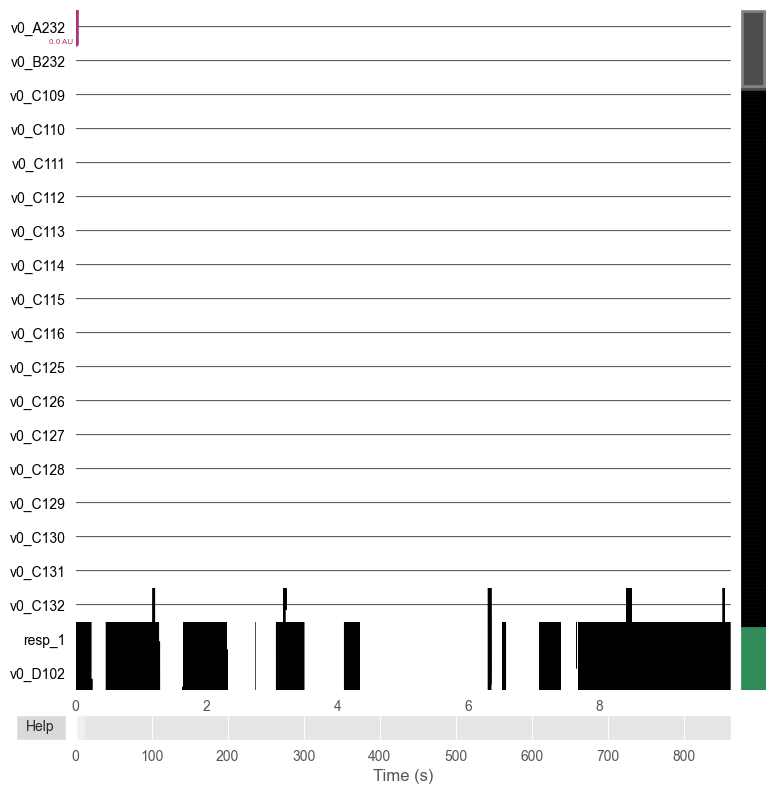

Effective window size : 2.048 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Plotting power spectral density (dB=True).
Need more than one channel to make topography for dbs. Disabling interactivity.


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/mne/time_frequency/psd.py:257: UserWarning: nperseg = 2048 is greater than input length  = 1, using nperseg = 1
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/mne/time_frequency/psd.py:257: UserWarning: nperseg = 2048 is greater than input length  = 50, using nperseg = 50
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/mne/time_frequency/psd.py:257: UserWarning: nperseg = 2048 is greater than input length  = 2, using nperseg = 2
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/mne/time_frequency/psd.py:257: UserWarning: nperseg = 2048 is greater than input length  = 2, using nperseg = 2
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/mne/time_frequency/psd.py:257: UserWarning: nperseg = 2048 is greater than input length  = 2, using nperseg = 2
/Library/Frameworks/Python.framework/V

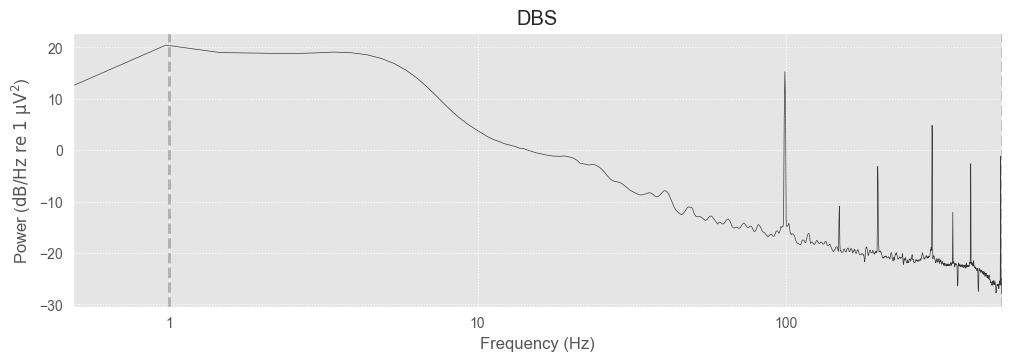

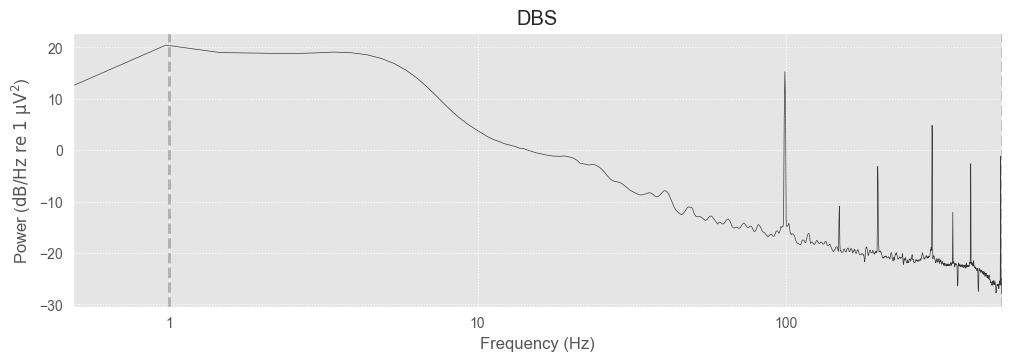

In [29]:
raw.plot(block=True)
raw.compute_psd(picks=['dbs_L1']).plot(xscale='log')

In [30]:
# # OLD VERSION with CAR
# raw_car = raw.copy()
# # COMMON AVERAGE REREF
# if np.any(['ecog' in c for c in raw.info['ch_names']]):
#     raw_car.set_eeg_reference(ref_channels='average', ch_type='ecog') # apply common average reference ref_channels='average'
# raw_car.plot(block=True)

# Compute spectrum--for the session and for each trial

In [31]:

# if len(PICKS_MACRO)>0: 
#     raw.compute_psd(picks=PICKS_MACRO).plot(xscale='log') 
# if len(PICKS_DBS)>0: 
#     raw.compute_psd(picks=PICKS_DBS).plot(xscale='log') 
# if len(PICKS_ECOG)>0: 
#     raw.compute_psd(picks=PICKS_ECOG).plot(xscale='log')

# savepath_psd = Path(f'./data_smsl/Z01_10_psd-over-trials-long_sub-{subject_id}_run-{run_id:02d}.tsv')
# mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"
savepath_psd = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/Z01_10_psd-over-trials-long_sub-{subject_id}_run-{run_id:02d}.tsv')

In [32]:
tmin, tmax = -1.5, 3
df = deepcopy(trials_df)
df['duration'] = 0
df['description'] = (
    "stimulus-on" + 
    "_run-" + df['run_id'].apply(lambda x: "{:02d}".format(x)) + 
    "_trial-" + df['trial_id'].apply(lambda x: "{:02d}".format(x))
    )
raw.set_annotations(bmlannot2mneannot(df))

events, events_map = mne.events_from_annotations(raw)
epochs = mne.Epochs(raw, 
                    events, 
                    event_id=events_map, 
                    baseline=None, 
                    tmin=tmin, tmax=tmax, preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)
# trials_selected_df = trials_df.iloc[epochs.selection] # retrieve the rows that mne extracted such that height(epochs)==height(trials)


Used Annotations descriptions: [np.str_('stimulus-on_run-01_trial-01'), np.str_('stimulus-on_run-01_trial-02'), np.str_('stimulus-on_run-01_trial-03'), np.str_('stimulus-on_run-01_trial-04'), np.str_('stimulus-on_run-01_trial-05'), np.str_('stimulus-on_run-01_trial-06'), np.str_('stimulus-on_run-01_trial-07'), np.str_('stimulus-on_run-01_trial-08'), np.str_('stimulus-on_run-01_trial-09'), np.str_('stimulus-on_run-01_trial-10'), np.str_('stimulus-on_run-01_trial-100'), np.str_('stimulus-on_run-01_trial-101'), np.str_('stimulus-on_run-01_trial-102'), np.str_('stimulus-on_run-01_trial-103'), np.str_('stimulus-on_run-01_trial-104'), np.str_('stimulus-on_run-01_trial-105'), np.str_('stimulus-on_run-01_trial-106'), np.str_('stimulus-on_run-01_trial-107'), np.str_('stimulus-on_run-01_trial-108'), np.str_('stimulus-on_run-01_trial-109'), np.str_('stimulus-on_run-01_trial-11'), np.str_('stimulus-on_run-01_trial-110'), np.str_('stimulus-on_run-01_trial-111'), np.str_('stimulus-on_run-01_trial-11

In [33]:
epochs_ta = epochs.copy().pick(picks=[c for c in epochs.info['ch_names'] if 'ecog_L25' in c]).filter(l_freq=5, h_freq=8, method='fir', phase='zero').apply_hilbert(envelope=True)

Setting up band-pass filter from 5 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 5.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 1651 samples (1.651 s)



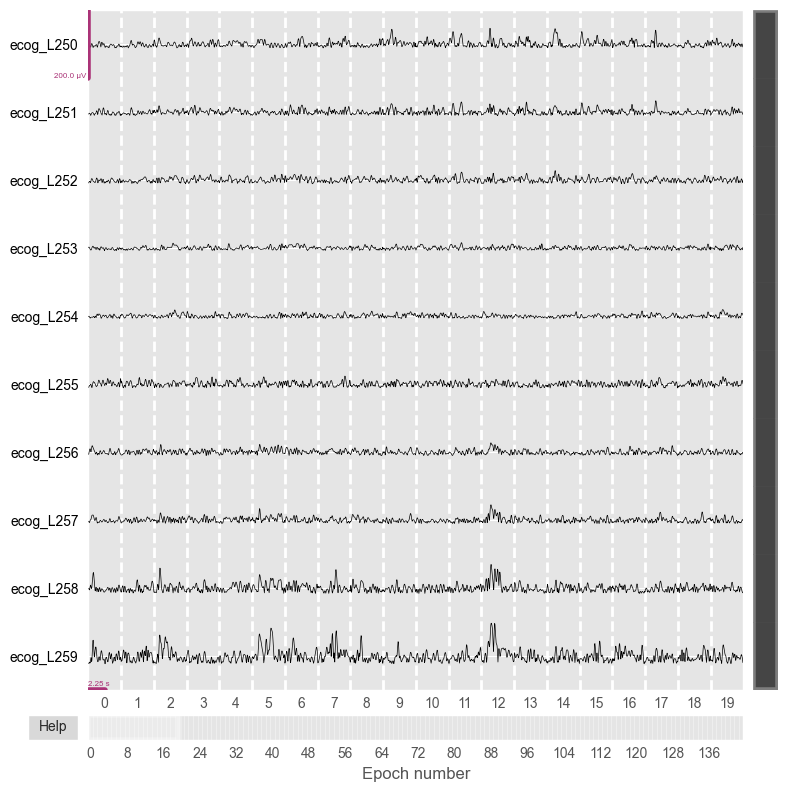

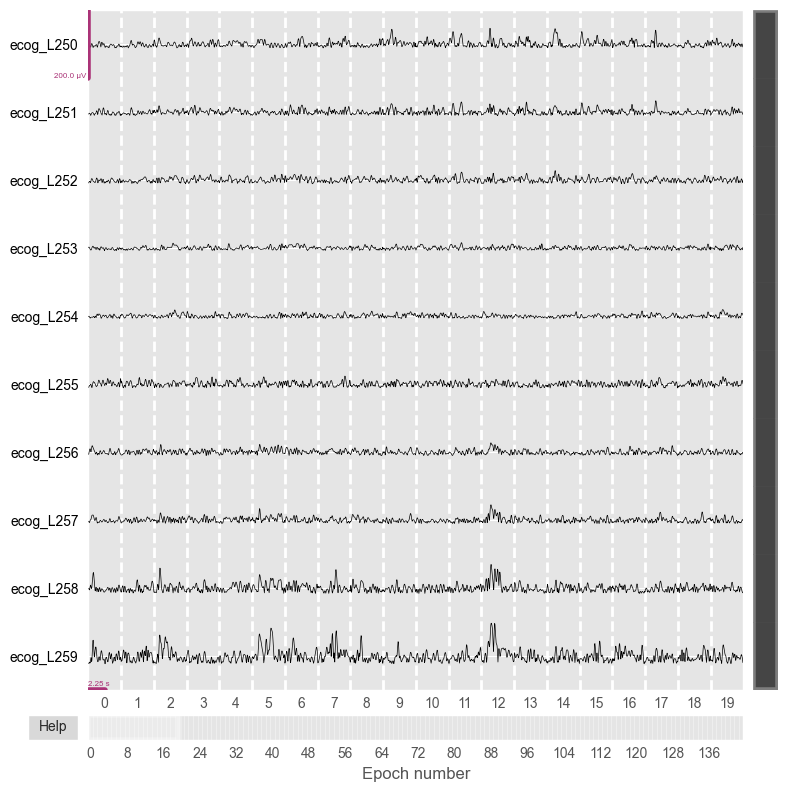

In [34]:

epochs_ta.plot(block=True)

In [35]:
tmin, tmax = -10, 10
df = deepcopy(trials_df)
df['duration'] = 0
df['description'] = (
    "stimulus-on" + 
    "_run-" + df['run_id'].apply(lambda x: "{:02d}".format(x)) + 
    "_trial-" + df['trial_id'].apply(lambda x: "{:02d}".format(x))
    )
raw.set_annotations(bmlannot2mneannot(df))


# if OVERRIDE_FLAG or not savepath_psd.exists(): 
if True: 

    events, events_map = mne.events_from_annotations(raw)
    epochs = mne.Epochs(raw, 
                        events, 
                        event_id=events_map, 
                        baseline=None, 
                        tmin=tmin, tmax=tmax, preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)
    # trials_selected_df = trials_df.iloc[epochs.selection] # retrieve the rows that mne extracted such that height(epochs)==height(trials)

    # PICKS_MACRO+PICKS_DBS+PICKS_ECOG
    psd_df = epochs.compute_psd(picks=PICKS_MACRO+PICKS_DBS+PICKS_ECOG).to_data_frame()

    # events
    # df[['event', 'run_id', 'trial_id']] = 
    psd_df[['event', 'run_id', 'trial_id']] = psd_df['condition'].str.extract(
        r'(?P<event>.+)_run-(?P<run_id>\d+)_trial-(?P<trial_id>\d+)', expand=True
    )
    psd_df[['run_id', 'trial_id']] = psd_df[['run_id', 'trial_id']].astype(int)
    psd_df['subject_id'] = subject_id
    # psd_df.head()

    psd_df['freq_bin'] = psd_df['freq'].floordiv(1).astype(int)  # or: np.floor(df['freq']).astype(int)

    # Step 2: Group by relevant columns, including the new freq_bin
    group_cols = ['condition', 'epoch', 'freq_bin', 'event', 'run_id', 'trial_id', 'subject_id']
    psd_df = psd_df.groupby(group_cols).mean(numeric_only=True).reset_index() # .rename(columns={'freq_bin': 'freq'})

    psd_df.head()

    psd_df.to_csv(savepath_psd, sep ='\t', index=False)
else: 
    print('Loading pre-calculated PSD')
    psd_df = pd.read_csv(savepath_psd, sep ='\t', index_col=0)



Used Annotations descriptions: [np.str_('stimulus-on_run-01_trial-01'), np.str_('stimulus-on_run-01_trial-02'), np.str_('stimulus-on_run-01_trial-03'), np.str_('stimulus-on_run-01_trial-04'), np.str_('stimulus-on_run-01_trial-05'), np.str_('stimulus-on_run-01_trial-06'), np.str_('stimulus-on_run-01_trial-07'), np.str_('stimulus-on_run-01_trial-08'), np.str_('stimulus-on_run-01_trial-09'), np.str_('stimulus-on_run-01_trial-10'), np.str_('stimulus-on_run-01_trial-100'), np.str_('stimulus-on_run-01_trial-101'), np.str_('stimulus-on_run-01_trial-102'), np.str_('stimulus-on_run-01_trial-103'), np.str_('stimulus-on_run-01_trial-104'), np.str_('stimulus-on_run-01_trial-105'), np.str_('stimulus-on_run-01_trial-106'), np.str_('stimulus-on_run-01_trial-107'), np.str_('stimulus-on_run-01_trial-108'), np.str_('stimulus-on_run-01_trial-109'), np.str_('stimulus-on_run-01_trial-11'), np.str_('stimulus-on_run-01_trial-110'), np.str_('stimulus-on_run-01_trial-111'), np.str_('stimulus-on_run-01_trial-11

In [36]:
# frequency bin,  aggregate, and plot
if OVERRIDE_FLAG: # control whether this is re-run
    freq_edges = np.array(list(np.logspace(np.log10(1), np.log10(100), 30)) + list(np.arange(110, 500, 10)))

    psd_df["freq_bin"] = pd.cut(
        psd_df["freq"],
        bins=freq_edges,
        labels=False,  # gives you bin indices (0 to 48)
        include_lowest=True
    )
    freq_centers = (freq_edges[:-1] + freq_edges[1:]) / 2
    group_cols = ['condition', 'epoch', 'freq_bin', 'event', 'run_id', 'trial_id', 'subject_id']
    psd_df = (
        psd_df
        .groupby(group_cols, observed=True)
        .mean(numeric_only=True)
        .reset_index()
    )

    id_vars = ['subject_id', 'run_id', 'trial_id', 'freq']
    psd_long_df = psd_df.drop(columns=['condition', 'epoch', 'event', 'freq_bin']).melt(id_vars=id_vars, )
    psd_long_df.head()
        
    # plot psds over time 
    splitby = 'trial_id' # None, 'trial_id'
    # ch = random.choice(psd_long_df['variable'].unique())
    for ch in PICKS_DBS+PICKS_MACRO+random.choices(PICKS_ECOG, k=10):  # random.choices(psd_long_df['variable'].unique(), 10)     psd_long_df['variable'].unique()
        df_plt = psd_long_df[psd_long_df.freq>2]
        df_plt = df_plt.query(f'variable=="{ch}"')
        # df_plt = df_plt.iloc[:10000]
        plt.cla()
        ax = sns.lineplot(df_plt, x='freq', y='value', errorbar='se', hue=splitby)
        ax.set(xscale='log', yscale='log')
        chid = f'sub-{subject_id}_run-{run_id}_ch-{ch}'
        ax.set_title(chid)
        plt.savefig(f'./fig/A01_10_single-channel-psd/A01_10_single-channel-psd_splitby-{splitby}_{chid}')

# Manually inspect raw data and mark bads

In [37]:
# picks = [c for c in raw.info['ch_names'] if re.match()]
picks = PICKS_MACRO + PICKS_DBS + PICKS_ECOG
# picks = PICKS_MACRO 

raw_mne_annotated = raw.copy().pick(picks=picks)

artifact_curr_df = artifact_all_df[['beta' not in s for s in  artifact_all_df.pname]]

raw_mne_annotated.set_annotations(bmlannot2mneannot(pd.concat([artifact_curr_df, trials_df])), on_missing='ignore')
# raw_mne_annotated.set_annotations(bmlannot2mneannot(artifact_all_df), on_missing='ignore')


<RawArray | 134 x 861654 (861.7 s), ~881.0 MiB, data loaded>

In [38]:
# raw_mne_annotated.plot(block=True)

In [39]:
# raw_mne_annotated.plot(block=True)
# raw_mne_annotated.plot(block=True)
raw_mne_annotated.info['bads']

[]

In [40]:
bad_chs = []
for c in raw_mne_annotated.info['bads']: 
    bad_chs.append({'onset': GTC_RUN_ONSET, 
                    'duration': GTC_RUN_OFFSET - GTC_RUN_ONSET,    
                    'channel': c,
                    'trial_id': np.nan,
                    'status': 'bad_channel',
                    'subject_id': subject_id, 
                    'run_id': run_id, 
                    'personnel': 'Latane Bullock', 
                    'method': 'mne data browser',
                    'timestamp': datetime.datetime.now().strftime("%Y-%m-%dT%H:%M:%S")})

# artifact_suffixes = ["artifact-criteria-A", "artifact-criteria-B", "artifact", "annot_artifact", "annot-artifact",  "artifact-criteria-manual"]
# art_all = []
# for suff in artifact_suffixes: 
#     p = subj_path  / "annot" / f"sub-{subject_id}_ses-intraop_task-lombard_{suff}.tsv"

if len(bad_chs) > 0: 
    df_new = pd.DataFrame(bad_chs)

    artifact_manual_fname = Path(f'sub-{subject_id}_ses-intraop_task-lombard_artifact-criteria-manual.tsv')
    savepath = subj_path  / "annot" / artifact_manual_fname
    if savepath.exists(): 
        df_orig = pd.read_csv(savepath, sep='\t')
        
        # copy to archive 
        shutil.copy2(subj_path  / "annot" / artifact_manual_fname, 
                    subj_path  / "annot" / "archive" / f'{artifact_manual_fname.stem}-{datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")}.tsv')
        
        df_new = pd.concat([df_orig, df_new]) 

    # df_new
    df_new.to_csv(savepath, sep='\t', index=False)


In [41]:
# filter artifacts for only those that intersect with the current run
artifact_all_df.offset = artifact_all_df.onset + artifact_all_df.duration
idxs_intersect = artifact_all_df.onset.apply(lambda t: max(t, GTC_RUN_ONSET)) < artifact_all_df.offset.apply(lambda t: min(t, GTC_RUN_OFFSET))
artifact_all_df = artifact_all_df[idxs_intersect]

idxs_bad = np.logical_or.reduce((artifact_all_df.status.str.contains('bad_channel', na=False),
                      artifact_all_df.description.str.contains('bad_channel', na=False),
                      artifact_all_df.duration > 200))
bad_chs = artifact_all_df['channel'][idxs_bad]

raw.info['bads'] = [c for c in raw.info['ch_names'] if c in list(bad_chs)]
raw.info['bads']

/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/2796712835.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access


[]

# Extract gamma

In [42]:
# extract_high_gamma()
import mne
import numpy as np
from scipy.signal import hilbert
from sklearn.decomposition import PCA

def extract_high_gamma(raw, fmin=70, fmax=200, n_bands=8, downsample_to=100, reject_prefix='bad_'):
    """
    Extract broadband high gamma signal from raw intracranial EEG data.

    Parameters
    ----------
    raw : mne.io.Raw
        The raw MNE object.
    fmin, fmax : float
        Frequency range for high gamma.
    n_bands : int
        Number of log-spaced frequency bands.
    downsample_to : float
        Target sampling rate for high gamma output.
    reject_prefix : str
        Prefix used in annotations for bad segments (default: "bad_").

    Returns
    -------
    raw_gamma : mne.io.Raw
        High gamma time series as a new Raw object (downsampled, z-scored).
    """
    raw = raw.copy().load_data()

    # Step 1: Drop bad segments
    if raw.annotations:
        bad_annot = [a for a in raw.annotations if a['description'].startswith(reject_prefix)]
        if bad_annot:
            raw.set_annotations(mne.Annotations([], [], []))  # remove all annotations
            raw.annotations.append(bad_annot)

        # raw = raw.copy().annotate_bad_segments(reject_by_annotation=True)

    # Step 2: Remove channels with all-NaN data
    good_chs = [ch for ch in raw.ch_names if not np.all(np.isnan(raw.get_data(picks=ch)))]
    raw.pick(good_chs)

    # Step 3: Define high gamma bands
    freqs = np.logspace(np.log10(fmin), np.log10(fmax), n_bands)
    bandwidth = np.diff(freqs).mean()

    # Step 4: Filter and extract log-Hilbert amplitude per band
    data_bands = []
    for cf in freqs:
        raw_band = raw.copy().filter(cf - bandwidth / 2, cf + bandwidth / 2,
                                     l_trans_bandwidth=1.0, h_trans_bandwidth=1.0,
                                     fir_design='firwin', phase='zero')
        analytic = hilbert(raw_band.get_data(), axis=1)
        amp = np.abs(analytic) # log_amp = np.log1p(amp)  # log(1 + x)
        data_bands.append(amp)

    # Step 5: PCA over log-amp bands
    data_bands = np.stack(data_bands, axis=0)  # (n_bands, n_channels, n_times)
    data_bands = np.transpose(data_bands, (1, 0, 2))  # (n_channels, n_bands, n_times)

    n_channels, _, n_times = data_bands.shape
    data_gamma = np.zeros((n_channels, n_times))

    for i in range(n_channels):
        pca = PCA(n_components=1)
        data_gamma[i] = pca.fit_transform(data_bands[i].T).squeeze()

    # Step 6: Create Raw object and resample
    info_gamma = mne.create_info(ch_names=raw.ch_names, sfreq=raw.info['sfreq'], ch_types='ecog')
    raw_gamma = mne.io.RawArray(data_gamma, info=info_gamma)
    raw_gamma.resample(sfreq=downsample_to)
    raw_gamma.set_meas_date(raw.info['meas_date'])

    # Step 7: Z-score
    raw_gamma._data = (raw_gamma._data - np.mean(raw_gamma._data, axis=1, keepdims=True)) / \
                      np.std(raw_gamma._data, axis=1, keepdims=True)

    return raw_gamma

# DM1033 ['ecog_L234', 'ecog_L233', 'ecog_L235']
# DM1007 ['ecog_L224', 'ecog_L225', 'ecog_L226']
# DM1022 ecog_L251 ['ecog_L250', 'ecog_L251', 'ecog_L252']
# DM1003 ecog_L233 ['ecog_L232', 'ecog_L233', 'ecog_L234']
# picks = ['ecog_L224', 'ecog_L225', 'ecog_L226']

# picks = [c for c in raw.info['ch_names'] if 'dbs' in c] +  [c for c in raw.info['ch_names'] if 'dbs' in c]


In [43]:
def _zscore_inplace(raw):
    X = raw.get_data()
    X -= X.mean(axis=1, keepdims=True)
    X /= (X.std(axis=1, keepdims=True) + 1e-12)

In [44]:
def extract_beta(
    raw,
    method="multiband_pca",          # "simple" or "multiband_pca"
    fmin=13.0, fmax=30.0,            # used when method="simple"
    bands=((8, 12), (12, 20), (20, 30)),  # used when method="multiband_pca"
    use_envelope=True,               # apply Hilbert envelope (default=True)
    downsample_to=100,               # Hz
    fir_kwargs=None,
    picks=None,
):
    """
    Extract a beta-band signal from an MNE Raw object.

    Parameters
    ----------
    raw : mne.io.Raw
        Input Raw (will not be modified).
    method : {"simple", "multiband_pca"}
        - "simple": bandpass fmin..fmax, return Hilbert envelope (default).
        - "multiband_pca": multiple beta sub-bands, envelope + PCA.
    fmin, fmax : float
        Beta band edges if method="simple".
    bands : sequence of (low, high)
        Sub-bands if method="multiband_pca".
    use_envelope : bool
        If True (default), apply Hilbert to get amplitude envelope.
        If False, return real bandpassed signal.
    downsample_to : float
        Target sampling rate for the returned Raw.
    fir_kwargs : dict or None
        Extra args to pass to Raw.filter.
    picks : list or None
        Channel picks to process.

    Returns
    -------
    raw_beta : mne.io.Raw
        Beta-band signal per channel, z-scored, resampled.
    """
    fir_defaults = dict(l_trans_bandwidth='auto',
                        h_trans_bandwidth='auto',
                        fir_design='firwin',
                        phase='zero')
    if fir_kwargs:
        fir_defaults.update(fir_kwargs)

    raw_in = raw.copy().load_data()
    if picks is None:
        picks = mne.pick_channels(raw_in.ch_names, include=raw_in.ch_names)

    ch_names = [raw_in.ch_names[i] for i in picks]
    ch_types = [raw_in.get_channel_types(picks=[i])[0] for i in picks]
    sfreq = raw_in.info['sfreq']

    if method == "simple":
        rb = raw_in.copy().pick(picks=picks)
        rb.filter(fmin, fmax, **fir_defaults)
        X = rb.get_data()

        if use_envelope:
            analytic = hilbert(X, axis=1)
            X = np.abs(analytic)

        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
        raw_beta = mne.io.RawArray(X, info)
        raw_beta.resample(downsample_to)
        _zscore_inplace(raw_beta)
        raw_beta.set_meas_date(raw_in.info.get('meas_date', None))
        return raw_beta

    elif method == "multiband_pca":
        band_traces = []
        for (lo, hi) in bands:
            rb = raw_in.copy().pick(picks=picks)
            rb.filter(lo, hi, **fir_defaults)
            X = rb.get_data()
            if use_envelope:
                analytic = hilbert(X, axis=1)
                X = np.abs(analytic)
            band_traces.append(X)

        data = np.stack(band_traces, axis=0).transpose(1, 0, 2)  # (n_ch, n_b, n_t)
        n_ch, n_b, n_t = data.shape

        beta_out = np.empty((n_ch, n_t), dtype=float)
        pca = PCA(n_components=1)
        for ci in range(n_ch):
            Y = np.nan_to_num(data[ci].T)  # shape (n_times, n_bands)
            beta_out[ci] = pca.fit_transform(Y).ravel()

        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
        raw_beta = mne.io.RawArray(beta_out, info)
        raw_beta.resample(downsample_to)
        _zscore_inplace(raw_beta)
        raw_beta.set_meas_date(raw_in.info.get('meas_date', None))
        return raw_beta

    else:
        raise ValueError("method must be 'simple' or 'multiband_pca'")





In [45]:
picks = PICKS_DBS + PICKS_MACRO + PICKS_ECOG
picks = PICKS_DBS
RAW_BAND = 'beta-simple' # gamma, beta-pca, or beta-simple

# savepath_gamma_raw = Path(f'./data/A01_00_raw-{RAW_BAND}/sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ieeg-{RAW_BAND}.fif')
savepath_gamma_raw = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/sub-{subject_id}_ses-intraop_task-smsl_run-{run_id:02d}_ieeg-{RAW_BAND}.fif')

if OVERRIDE_FLAG or not savepath_gamma_raw.exists(): 
    match RAW_BAND: 
        case 'gamma':
            raw_gamma = extract_high_gamma(raw.copy().pick(picks=picks))
        case 'beta-simple':
            raw_gamma = extract_beta(
                raw.copy().pick(picks=picks),
                method="simple",          # "simple" or "multiband_pca"
                fmin=13.0, fmax=30.0,            # used when method="simple"
                use_envelope=True,               # apply Hilbert envelope (default=True)
                downsample_to=100,               # Hz
                fir_kwargs=None,
                picks=None,
            )
        case 'beta-pca': 
            raw_gamma = extract_beta(
                raw.copy().pick(picks=picks),
                method="multiband_pca",          # "simple" or "multiband_pca"
                bands=((8, 12), (12, 20), (20, 30)),  # used when method="multiband_pca"
                use_envelope=True,               # apply Hilbert envelope (default=True)
                downsample_to=100,               # Hz
                fir_kwargs=None,
                picks=None,
            )

    raw_gamma.save(savepath_gamma_raw, overwrite=True) 
else: 
    print('Loading pre-calculated gamma traces')
    raw_gamma = mne.io.read_raw(savepath_gamma_raw)


channel_type_mapping = {}
for c in raw_gamma.ch_names: 
    if 'ecog' in c: channel_type_mapping[c] = 'ecog'
    elif ('dbs' in c) or ('macro' in c): channel_type_mapping[c] = 'dbs'
raw_gamma.set_channel_types(channel_type_mapping)

raw_gamma

Loading pre-calculated gamma traces
Opening raw data file /Users/rohandeshpande/Documents/School/Research/Code/Z01/sub-DM1025_ses-intraop_task-smsl_run-01_ieeg-beta-simple.fif...
Isotrak not found
    Range : 0 ... 86164 =      0.000 ...   861.640 secs
Ready.


/var/folders/c9/49f2z5xj4790fdlvhdmygvzc0000gn/T/ipykernel_29940/1903164281.py:36: RuntimeWarning: This filename (/Users/rohandeshpande/Documents/School/Research/Code/Z01/sub-DM1025_ses-intraop_task-smsl_run-01_ieeg-beta-simple.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz


<Raw | sub-DM1025_ses-intraop_task-smsl_run-01_ieeg-beta-simple.fif, 8 x 86165 (861.6 s), ~14 KiB, data not loaded>

In [46]:
[c for c in raw_gamma.ch_names if 'dbs' in c]

['dbs_L1',
 'dbs_L2A',
 'dbs_L2B',
 'dbs_L2C',
 'dbs_L3A',
 'dbs_L3B',
 'dbs_L3C',
 'dbs_L4']

In [47]:
# Plot evoked gamma sentence-wise

# Warp gamma trial-wise

In [48]:
def build_epochs_df(epochs): 
    events_df = pd.DataFrame({'event_raw_idx': epochs.events[:, 0],
                            'event_id': epochs.events[:, 2]})

    events_mapping = pd.DataFrame({'event_description': epochs.event_id.keys(), 
                                    'event_id': epochs.event_id.values()})

    events_mapping[['event_type', 'run_id', 'trial_id']] = events_mapping['event_description'].str.extract(
            r'(?P<event>.+)_run-(?P<run_id>\d+)_trial-(?P<trial_id>\d+)', expand=True
            )
    events_mapping[['run_id', 'trial_id']] = events_mapping[['run_id', 'trial_id']].astype(int)

    events_df = events_df.merge(events_mapping, how='left', on='event_id')
    return events_df

In [49]:
# set up trials_df to include landmarks for each trial
LANDMARKS = [('trial_on', -1.0),
 ('stimulus_on', 0.0),
 ('stimulus_off', 2.0),
 ('go_cue', 2.5),
 ('speech_on', 3.0), 
('speech_off', 6.0), ('trial_off', 10)]

LANDMARKS_WITH_WORDS = (
    [('trial_on', -1.0),
    ('stimulus_on', 0.0),
    ('stimulus_off', 2.0),
    ('go_cue', 2.5),
    ('speech_on', 3.0)] + 
    [(f'word_{i+1}', np.nan) for i in range(1,10)] + 
    [('speech_off', 6.0), ('trial_off', 10)]
)



trials_detailed_df = deepcopy(trials_df)
sentences_tmp_df = deepcopy(sentences_df)

cols_key = ['trial_id', 'run_id']
mapper = {'onset': 'speech_onset', 'duration': 'speech_duration'}
cols_oi = ([*mapper.values()] +  cols_key)

sentences_tmp_df = sentences_tmp_df.rename(columns=mapper)[cols_oi] # ['trial_id',' run_id', 'speech_onset', 'speech_duration']

# sentences_tmp_df
# WORDS_PER_TRIAL = WORDS_PER_TRIAL.query(f'subject_id == "{subject_id}" and run_id=={run_id}')
# COHORT_WORD_ONSET_PER_SENTID 

trials_detailed_df = pd.merge(trials_df, sentences_tmp_df, how='left', on=cols_key)

trials_detailed_df = pd.merge(trials_detailed_df, WORDS_PER_TRIAL, how='left', on=cols_key)
warpto_cols = trials_detailed_df.columns[trials_detailed_df.columns.str.endswith('warpto')]
trials_detailed_df[warpto_cols] = trials_detailed_df[warpto_cols] + 3

for m, t in LANDMARKS: 
    trials_detailed_df[f'{m}_warpto'] = t

trials_detailed_df['trial_on'] = trials_detailed_df['onset'] - 1
trials_detailed_df['stimulus_on'] = trials_detailed_df['audio_onset']
trials_detailed_df['stimulus_off'] = trials_detailed_df['audio_onset'] + trials_detailed_df['audio_duration']
trials_detailed_df['go_cue'] = trials_detailed_df['go_time']
trials_detailed_df['speech_on'] = trials_detailed_df['speech_onset']
trials_detailed_df['speech_off'] = trials_detailed_df['speech_on'] + trials_detailed_df['speech_duration']
trials_detailed_df['trial_off'] = trials_detailed_df['speech_off'] + 1
# trials_detailed_df['trial_off'] = trials_detailed_df['trial_on'] + 6.0

# trials_detailed_df = trials_detailed_df[trials_detailed_df]

# mapper = {'onset': 'trial_on', 'duration': 'speech_duration'}
# trials_detailed_df.rename()
cols_events = [marker for marker, markert in LANDMARKS]
trials_detailed_df['onset_gtc'] = trials_detailed_df['stimulus_on']
trials_detailed_df[cols_events] = trials_detailed_df[cols_events].subtract(trials_detailed_df['stimulus_on'], axis=0).dropna()
trials_detailed_df = trials_detailed_df.dropna(subset='onset_gtc')

# filter out unreasonably long trials
trials_detailed_df = trials_detailed_df[trials_detailed_df.trial_off<10]

word_cols = [f'word_{i+1}' for i in range(10)]
trials_detailed_df[word_cols] = trials_detailed_df[word_cols].add(trials_detailed_df['speech_on'], axis=0)

idxs_bad = np.sum(~np.isnan(trials_detailed_df[[m for m,t in LANDMARKS_WITH_WORDS]].values), axis=1) < 5 # these are trials that have few landmarks/word annotations
trials_detailed_df = trials_detailed_df[~idxs_bad]

# inspect each trial
trials_detailed_df[['onset_gtc'] + [m for m,t in LANDMARKS_WITH_WORDS] + [f'{m}_warpto' for m,t in LANDMARKS_WITH_WORDS]]

# remove excessively long trials
trials_detailed_df = trials_detailed_df[trials_detailed_df.duration < 9.5]



KeyError: 'audio_duration'

In [ ]:
# verify this warping method with by sneaking in stim channels
# assert 0, 'TEMPorarily subbing in audio and raw'
# raw_gamma = raw.copy().pick(picks=['envaudioAEC_p', 'envaudio_s'])
# picks_beh = [c for c in raw.ch_names if all(x not in c for x in ['ecog', 'dbs', 'macro', 'v0', 'micro'])]
# picks_beh = set(raw.ch_names) - set(PICKS_DBS + PICKS_ECOG + PICKS_MACRO)
# picks_beh

In [ ]:
sfreq_gamma = 100
# picks_beh = ['ema_L_pc1', 'ema_T_pc1', 'ema_J_pc1'] # acousticspectrum_intensity, envaudio_s
picks_beh = [c for c in raw.ch_names if all(x not in c for x in ['ecog', 'dbs', 'macro', 'v0', 'micro'])]

raw_beh = raw.copy().pick(picks=picks_beh).resample(sfreq=sfreq_gamma)

raw_gamma_beh = raw_gamma.copy().load_data().add_channels([raw_beh.load_data()], force_update_info=True)

In [ ]:

tmin, tmax = -1, 10 # min and max of epoching

df = deepcopy(trials_detailed_df)
df['onset'] = df['onset_gtc'] # onset_gtc = stimulus_on for each trial
df['duration'] = 0
df['description'] = (
    "stimulus-on" + 
    "_run-" + df['run_id'].apply(lambda x: "{:02d}".format(x)) + 
    "_trial-" + df['trial_id'].apply(lambda x: "{:02d}".format(x))
    )
raw_gamma_beh.set_annotations(bmlannot2mneannot(df))
df


In [ ]:

# events, events_map = mne.events_from_annotations(raw_gamma)
epochs_gamma = mne.Epochs(raw_gamma_beh, 
                            events=None, # use annotations
                            baseline=None, 
                            tmin=tmin, tmax=tmax, preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)
# trials_detailed_df = trials_detailed_df.iloc[epochs_gamma.selection] # retrieve the rows that mne extracted such that height(epochs)==height(trials)

# assert (epochs_gamma.get_data().shape[0]==len(df)), 'Epoching failed'
# assert (epochs_gamma.events.shape[0]==len(df)), 'Epoching failed'

events = pd.DataFrame(epochs_gamma.events, columns=['event_sample_idx', '_dum', 'event_id'])
events_map = pd.DataFrame({'event_name': epochs_gamma.event_id.keys(), 'event_id': epochs_gamma.event_id.values()})

events = pd.merge(events, events_map, how='left', on='event_id')
events[['event_name', 'run_id', 'trial_id']] = events['event_name'].str.extract(
    r'(?P<event>.+)_run-(?P<run_id>\d+)_trial-(?P<trial_id>\d+)', expand=True
)
events[['run_id', 'trial_id']] = events[['run_id', 'trial_id']].astype(int)

events = pd.merge(events, trials_detailed_df, how='left', on=['run_id', 'trial_id'])


ntrials, nchans, ntimes = epochs_gamma.get_data().shape
new_data = np.empty(epochs_gamma.get_data().shape) * np.nan


# tmin, tmax = min([t for m,t in LANDMARKS]), max([t for m,t in LANDMARKS])
tmin, tmax = -1, 10
timevec_new = epochs_gamma.times[np.logical_and(epochs_gamma.times>=tmin, epochs_gamma.times<=tmax)]
new_data = np.empty((ntrials, nchans, len(timevec_new))) * np.nan

itrial = 0 
for itrial in range(ntrials): 
    x1 = events.iloc[[itrial]][[m for m,t in LANDMARKS_WITH_WORDS]]
    x2 = events.iloc[[itrial]][[f'{m}_warpto' for m,t in LANDMARKS_WITH_WORDS]]
    x2.columns = x2.columns.str.removesuffix('_warpto')
    z = pd.concat([x1, x2], axis=0).dropna(axis=1)

    t_interp_func = scipy.interpolate.interp1d(z.values[1, :], 
                                               z.values[0, :], 
                                               kind='linear') # or 'cubic', etc.

    grab_times = t_interp_func(timevec_new)
    # print(new_data.shape)
    # grab_idxs[0, :, :] = epochs_gamma.time_as_index(grab_times)
    # plt.plot(grab_idxs = epochs_gamma.time_as_index(grab_times))
    trial_data = epochs_gamma.get_data()[itrial, :, :]
    new_data[itrial, :, :] = trial_data[:, epochs_gamma.time_as_index(grab_times)]
# epochs_gamma.get_data()[[11, 12], :, [101, 102, 103]].shape

epochs_gamma_warped = epochs_gamma.copy().crop(tmin, tmax)
epochs_gamma_warped._data = new_data


In [ ]:
savepath_gamma_epochs_warped = Path(f'./data/A01_00_epoched-warped-{RAW_BAND}/sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_wordwise_ieeg-{RAW_BAND}-epo')
epochs_gamma_warped.save(f'{savepath_gamma_epochs_warped}.fif', overwrite=True)
events.to_csv(f'{savepath_gamma_epochs_warped}.tsv', sep='\t', index=False)

In [ ]:
# # audio channels are envaudio_s, envaudioAEC_p
# picks = []
# df = epochs_gamma_warped.copy().pick(picks).to_data_frame(index='epoch').drop(['envaudio_s', 'condition'], axis=1).reset_index().pivot(index=['epoch'], columns='time', values='envaudioAEC_p')
# df = df.merge(events['sentence_id_x'], how='left', left_index=True, right_index=True).sort_values(by='sentence_id_x')

# # df.merge(events[['trial_id', 'sentence_id_x']], how='left', on='trial_id')
# sns.heatmap(df, cmap='Reds',  fmt='.3f') # , vmax=60000) # vmax=0.1, vmin=0
# plt.savefig(Path('./fig') / f'A01_02_warped_epoched_audiosanitycheck_sub-{subject_id}_run-{run_id:02d}.png')



In [ ]:
# picks = ['ecog_L113', 'ecog_L163', 'ecog_L115', 'ecog_L116']
# epochs_gamma_warped.info['ch_names']
# DM1022 r3 ecog_L107
# epochs_gamma_warped.copy()[].average(picks=picks).apply_baseline(baseline=(-1,0)).plot_image(picks=picks)

# Plot sentence-wise evoked gamma 

In [ ]:
# [c for c in epochs_run[idxs_good_sent].ch_names if 'macro' in c]
# [c for c in epochs_gamma.ch_names if 'macro' in c]
# PICKS_MACRO

# channel_id
# epochs_run[idxs_good_sent]

In [ ]:
analysis_prefix = f'A02_01_single-channel-warped-{RAW_BAND}-sentencewise'
dir_fig = Path(f'./fig/{analysis_prefix}')
dir_fig.mkdir(exist_ok=True)

epochs_run = epochs_gamma_warped.copy()
events_df = build_epochs_df(epochs_run)
events_df = events_df.merge(trials_df, how='left', on=['run_id', 'trial_id'])

ylim_all = None # None, or [min max], [-0.4, 1.7]

epochs_run.set_channel_types({c:'ecog' for c in epochs_run.info['ch_names'] if 'ecog' in c})

chs = ['envaudio_s', 'acousticspectrum_intensity', 'ema_J_pc1', 'ema_T_pc1', 'ema_TTX', 'ema_LIX', 'ema_LIY'] + PICKS_MACRO + PICKS_DBS + PICKS_ECOG 


t = f'sub-{subject_id}_run-{run_id:02d}_ch-ecog_L101'
if OVERRIDE_FLAG or not (dir_fig / f'{analysis_prefix}_{t}.png').exists():

    for ch in chs:
        channel_id = subject_id + "r" + (str(run_id)) + ch
        
        # # fishing for specific channel
        # if not (subject_id=="DM1003" and run_id==4 and ch=="ecog_L233"): 
        #     print('\n\n') 
        #     continue

        # if channel_id not in ch_subset: 
        #     # print(f'{channel_id} NOT in ch_subset')
        #     continue
        # print(f'{channel_id} FOUND in ch_subset')

        idxs_good = np.ones(events_df.shape[0]).astype(bool)
        if f'bad_{ch}' in events_df.columns: 
            idxs_good = (idxs_good) & (~events_df[f'bad_{ch}'].astype(bool))
        if np.sum(idxs_good) < 30: continue
        
        # # # op1 ------------------------------------------------------------
        # evoked_ch = epochs_run[idxs_good].pick(picks=ch).average(picks=ch).apply_baseline(baseline=(-0.5, 0))

        # evoked_all[ich, :] = evoked_ch.get_data()
        # evoked_all_df.append({'subject_id' : subject_id, 'run_id': run_id, 'channel': ch})
        # ich += 1

        # op2... or, further split up by sentnece_id ----------------
        nsent = 10
        fig, axs = plt.subplots(nsent, 1, figsize=(4, 8), sharex=True, sharey=True)
        plt.tight_layout()
        for iax, hax in enumerate(axs): 
            idxs_good_sent = idxs_good & (events_df['sentence_id']==(iax+1))
            if idxs_good_sent.sum() < 3: continue 
            
            # plotting routine to see if we see any sentence-specific effects 
            if ch not in epochs_run[idxs_good_sent].ch_names: continue
            epochs_run_sent = epochs_run[idxs_good_sent].pick(picks=ch).apply_baseline(baseline=(-0.75, 0), verbose=True)
            # epochs_run_sent = epochs_run_sent.apply_function(bml_baseline, picks=ch, times=epochs_run_sent.times)
            X_bsln = epochs_run_sent.copy().crop(-0.5, 0).get_data()
            print(f'{X_bsln.shape}, {np.mean(X_bsln.ravel())}')
            
            df = epochs_run_sent.copy().crop(-1, 7).to_data_frame(scalings=dict(ecog=1, dbs=1), long_format=True)
            hax.axhline(0, color='gray', linestyle='-')
            sns.lineplot(
                data=df,
                x='time',
                y='value',
                hue=None, # if 'epoch', plot every setnence. 
                errorbar='se',  # ci or se
                estimator='mean', 
                legend=False,
                ax=hax
            )
            [hax.axvline(x+3, color='gray', linestyle='--') for x in COHORT_WORD_ONSET_PER_SENTID.iloc[iax, 1:11]]
            wstart = COHORT_WORD_ONSET_PER_SENTID.iloc[iax].sentence.split()[0]
            wend = COHORT_WORD_ONSET_PER_SENTID.iloc[iax].sentence.split()[-1]
            hax.set_ylabel(f'{wstart}..{wend}', rotation=45, va='top')

            evoked_ch = epochs_run_sent.average(picks=ch).apply_baseline(baseline=(-0.5, 0))
            # X_bsln = evoked_ch.copy().crop(-0.5, 0).get_data()
            # print(f'evoked: {X_bsln.shape}, {np.mean(X_bsln.ravel())}')
            
            # evoked_all[ich, :] = evoked_ch.get_data()
            # evoked_all_df.append({'subject_id' : subject_id, 'run_id': run_id, 'channel': ch, 'sentence_id': iax+1})
            # ich += 1


        # for iax, ax in enumerate(axs):
        #     if iax==(len(axs)-1): continue
        #     ax.set_xticklabels([])
        #     ax.set_xticks([])
        #     ax.set_xlabel('')
        fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0) # Set padding to zero
        if ylim_all is None: 
            ymin, ymax = axs[0].get_ylim()
            axs[0].set_ylim([ymin, ymax*0.8]) 
        else: axs[0].set_ylim(ylim_all) 

        t = f'sub-{subject_id}_run-{run_id:02d}_ch-{ch}'
        fig.suptitle(t, fontsize=16, y=1.05)

        fig.savefig(dir_fig / f'{analysis_prefix}_{t}.png', bbox_inches='tight')

        axs[0].set_xlim([2.5, 5.5])

        fig.savefig(dir_fig / f'{analysis_prefix}_{t}_zoom.png', bbox_inches='tight')
        plt.close(fig)

# Get window-based gamma power for cohort tabulation

In [ ]:
# tmin, tmax = -1, 7
# baseline = (-1, 0)  # baseline interval (in s)
# tlock = 'trial_*'

# tmin, tmax = -6, 1
# baseline = (0,1)  # baseline interval (in s)
# tlock = 'sentence-off_*'

# tmin, tmax = -1, 1
# baseline = (0,1)  # baseline interval (in s)
# # tlock = 'sentence-on_*'
# event_types = ['vowel-off_lips', 'vowel-off_tongue'] 

# raw_gamma.set_meas_date(raw.info['meas_date'])
# raw_gamma.set_annotations(annotations, on_missing='warn')
# events, events_map = mne.events_from_annotations(raw_gamma)
savepath_window_gamma = Path(f'./data/A01_01_windowed-{RAW_BAND}-pwr-data-long_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"

picks = ['envaudio_s', 'acousticspectrum_intensity', 'ema_J_pc1', 'ema_T_pc1', 'ema_TTX', 'ema_LIX', 'ema_LIY'] + PICKS_MACRO + PICKS_DBS + PICKS_ECOG 
# picks.reverse()
tlocks =[['BSLN', 'trial-on*', (-0.5, 0)], 
        ['STIM1', 'trial-on*', (0, 0.5)], 
        ['STIM2', 'trial-on*', (1.5, 2)], 
        ['PREP1', 'sentence-on*', (-1, -0.5)], 
        ['PREP2', 'sentence-on*', (-0.5, 0)], 
        ['SPEECH1', 'sentence-on*', (0, 0.5)],
        ['SPEECH2', 'sentence-on*', (0.5, 1)],
        ['SPEECH3', 'sentence-off*', (-0.5, 0)]]


if OVERRIDE_FLAG or not (savepath_window_gamma.exists()): # OVERRIDE_FLAG = OVERRIDE_FLAG_og
# if True or not (savepath_window_gamma.exists()): # force override for this section
    win_data_all = []
    for win, tlock, twin in tlocks: 
        for ch in picks: 
            artifact_ch_df = artifact_all_df[artifact_all_df['channel']==ch]
            annots_ch = bmlannot2mneannot(pd.concat([artifact_ch_df, annot_beh_all_df]))
            
            if ch not in raw_gamma.info['ch_names']: continue

            raw_gamma_ch = raw_gamma.copy().pick(picks=ch).set_annotations(annots_ch)
            
            events, events_map = mne.events_from_annotations(raw_gamma_ch, regexp=tlock)

            epochs = mne.Epochs(raw_gamma_ch, 
                                events, 
                                event_id=events_map, 
                                baseline=None, 
                                tmin=twin[0], tmax=twin[1], preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)
            if len(epochs.selection) < 10: continue
            
            df = epochs.to_data_frame(scalings=dict(ecog=1, dbs=1), long_format=True)
            df_avg = df.groupby('epoch').agg({
                'value': 'mean',
                'condition': 'first',
                'channel': 'first',
                'ch_type': 'first'
            }).reset_index()
            df_avg['win'] = win
            df_avg['subject_id'] = subject_id
            df_avg['run_id'] = run_id

            win_data_all.append(df_avg)

    win_data_all = pd.concat(win_data_all)

    win_data_all.win = pd.Categorical(win_data_all.win, 
                                    categories=[w for w, _, _ in tlocks],
                                    ordered=True)

    win_data_all.to_csv(savepath_window_gamma, sep ='\t', index=False)


win_data_all = pd.read_csv(savepath_window_gamma, sep='\t')  

# (epochs
# #  .resample(10)
# #  .apply_baseline(baseline)
#  .plot_image(picks=picks, group_by=['vowel-off_lips', 'vowel-off_tongue'])
# )

# evks = [epochs[e].average() for e in event_types]

# epochs.resampe(10)
# epochs.resample(10).apply_baseline(baseline).to_data_frame(scalings=dict(ecog=1, dbs=1), long_format=True)
# events_map

# mne.viz.plot_compare_evokeds(evks, picks=picks)

# mne.events_from_annotations(raw_gamma)



In [ ]:
# savepath = Path(f'./data/A01_01_windowed-gammapwr-data-long_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"
# win_data_all = pd.read_csv(savepath, sep='\t')  

In [ ]:
tmp = ['ecog_L232', 'ecog_L233', 'ecog_L249', 'ecog_L250', 'dbs_L2', 'macro_Ll', 'macro_Lc', 'macro_Lp']
# df[df.channel.isin(tmp)]
# df.channel

In [ ]:
# win_data_all.win = pd.Categorical(win_data_all.win, 
#                                 categories=[w for w, _, _ in tlocks],
#                                 ordered=True)
# df = win_data_all

# df
# p= (
#     p9.ggplot(
#         df[df.channel.isin(tmp)],
#         p9.aes(x="win", y="value"),
#     )
#     + p9.geom_point(position="jitter") 
#     + p9.geom_boxplot()
#     + p9.facet_wrap("channel", scales='free_y') 
#     + p9.theme(axis_text_x=p9.element_text(rotation=90, hjust=1), figure_size=(10, 10))
# )
# p.show()

# savepath = Path(f'./fig/A01_01_hand-selection-responsive-chans_sub-{subject_id}_run-{run_id:02d}.pdf')
# p.save(savepath)


In [ ]:
# Load setnences tsv for splitting gamma data below
sentences_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_task-lombard_annot-produced-sentences-acoustics.tsv" 
sentences_df = pd.read_csv(sentences_tsv, sep='\t')

sentences_df = sentences_df.merge(trials_df[['run_id', 'trial_id', 'sentence_id']], how='left', on=['run_id', 'trial_id'])
# Choose number of loudness bins
n_loudness = 2

# Apply qcut within each subject_id × run_id group
def bin_loudness(g):
    g = g.copy()
    g['loudness'] = pd.qcut(
        g['intensity_praat'],
        q=n_loudness,
        labels=[f"loudness{i+1}of{n_loudness}" for i in range(n_loudness)]
    )
    return g

sentences_df = sentences_df.groupby(['run_id'], group_keys=False).apply(bin_loudness)
# plt.ion()
sns.stripplot(sentences_df, x='loudness', y='intensity_praat', hue='sentence_id')
# plt.close('all')


In [ ]:
def detect_outliers(df, column):
    # Find first and third quartile
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    
    # Find interquartile range
    IQR = q3 - q1
    
    # Find lower and upper bound
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    
    # Remove outliers
    
    # df[column] = df[column][df[column] < lower_bound]
    # df[column] = df[column][df[column] > upper_bound]
    
    return (df[column] < lower_bound) | (df[column] > upper_bound)

df1 = pd.DataFrame({'no_of_trainings':[1,2,3,4,5,1000,6,7,8,9,10],
                    'other_data':[1,2,3,4,5,9,6,7,8,9,10]})

df1['outlier'] = detect_outliers(df1, 'no_of_trainings')
# df1

In [ ]:
plt.ion()

# Run wilcoxon and t tests on each channel 
import statsmodels.api as sm
import statsmodels.formula.api as smf

# in case the variable has been reset, read the table from disk
# savepath = Path(f'./data/A01_01_windowed-data-long_sub-{subject_id}_run-{run_id:02d}.tsv')
# savepath = Path(f'./data/A01_01_windowed-gammapwr-data-long_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"
# win_data_all = pd.read_csv(savepath, sep='\t')  
# win_data_all = pd.read_csv(savepath_window_gamma, sep='\t')  
# del sub_df 

analysis_prefix = f'A01_02_windowed-{RAW_BAND}-pwr-summarized-by-channel'

dir_fig = Path(f'./fig/{analysis_prefix}')
dir_fig.mkdir(exist_ok=True)
savepath_window_gamma_summarized = Path(f'./data/{analysis_prefix}_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"

if OVERRIDE_FLAG or not savepath_window_gamma_summarized.exists():
    results = [] 
    baseline = "BSLN"
    for ch, sub_df in win_data_all.groupby('channel'):
        row = {'channel': ch, 'subject_id': subject_id, 'run_id': run_id}
        base_vals = sub_df[sub_df['win'] == baseline]['value'].values

        for win in [w for w, _, _ in tlocks]:
            test_vals = sub_df[sub_df['win'] == win]['value'].values
            # print(win)
            if len(base_vals) > 0 and len(test_vals) > 0:
                row[f"{win}_wilcox_stat"], row[f"{win}_wilcox_p"] = ranksums(test_vals, base_vals)
                row[f"{win}_ttest_stat"], row[f"{win}_ttest_p"] = ttest_ind(test_vals, base_vals, equal_var=True)
            else:
                pval = np.nan

        # RUN ANOVA (to detect loudness coding)  and then plot 
        # left-join sub_df with sentences_df and run linear model, append column to row
        sub_df["trial_id"] = sub_df["condition"].str.extract(r'trial-(\d+)')[0].astype(int)
        sub_df = sub_df.merge(sentences_df[['trial_id', 'run_id', 'loudness', 'noise_type']], how='left', on=['trial_id', 'run_id'])
        
        win = 'SPEECH1'
        win_df = sub_df[sub_df['win'].isin(['BSLN', win])].copy()
        win_df['outlier'] = detect_outliers(win_df, 'value')

        for suf in ['', '_nooutliers']: 
            data = win_df[~win_df['outlier']] if suf=='_nooutliers' else  win_df
            model = smf.ols('value ~ win * loudness', data=data).fit() # doesn't account 
            d1 = model.pvalues.add_suffix(suf).to_dict()
            d2 = model.params.add_suffix(suf).to_dict()
            row = {**row, **d1, **d2}

            # row[f"{win}_win_loud_int_p{suf}"] = model.pvalues.get('win[T.SPEECH1]:loudness[T.loudness2of2]', np.nan)
            # row[f"{win}_win_main_p{suf}"] = model.pvalues.get('win[T.SPEECH1]', np.nan)
            # row[f"{win}_loud_main_p{suf}"] = model.pvalues.get('loudness[T.loudness2of2]', np.nan)

        # plot data
        win_df['win_loudness'] = win_df['win'].astype(str) + "_" + win_df['loudness'].astype(str)

        fig, ax = plt.subplots(1, 1, figsize=(4, 3))
        sns.stripplot(
            data=win_df.reset_index(),  # flatten just for seaborn
            y='win_loudness',
            x='value',
            hue='noise_type', #style='outlier',
            jitter=True
        )
        sns.stripplot(
            data=win_df[win_df['outlier']].reset_index(),  # flatten just for seaborn
            y='win_loudness',
            x='value',
            marker="D",
            jitter=True
        )
        sns.boxplot(
            data=win_df.reset_index(),  # flatten just for seaborn
            y='win_loudness',
            x='value', 
            color='white'
        )
        t = f'{analysis_prefix}_sub-{subject_id}_ch-{ch}_run-{run_id:02d}.png'

        fig.savefig(dir_fig / t, bbox_inches='tight')
        plt.close()

        results.append(row)
        # break
        
    pd.DataFrame(results).to_csv(savepath_window_gamma_summarized, sep ='\t', index=False)


In [ ]:
# # plot straightforward gamma extraction with one band
# picks = ['ecog_L249']
# tmin, tmax = -1, 7
# baseline = [-1, 0]
# raw.set_annotations(bmlannot2mneannot(pd.concat([annot_beh_all_df])))
# events, events_meta = mne.events_from_annotations(raw, regexp='trial*') # 
# epochs = mne.Epochs(raw, events, event_id=events_meta, baseline=None, tmin=tmin-0.5, tmax=tmax+0.5, preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)


In [ ]:
# epochs_gamma = (epochs.copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True)
#                 .crop(tmin, tmax).apply_baseline(baseline)
#                 .plot_image(picks=picks)
#                 )


# epochs.plot(picks=picks)
# epochs.plot_image(picks=picks, combine="mean")

# epochs.apply_baselin()
# epochs.plot_image()


# epochs_gamma

# epochs.compute_psd(picks=picks).plot(picks=picks, exclude="bads", amplitude=False)


# Sentence specificity: Channel trialwise spectral clustering

In [ ]:
def perm_pvals_for_clustering(labels_true, labels_pred, n_perm=1000, rng=None):
    """
    Permutation test for clustering alignment.
    Keeps labels_pred fixed (from spectral clustering on S),
    shuffles labels_true, and recomputes ARI/NMI to build a null.
    Returns dict with obs stats and p-values (right-tailed).
    """
    if rng is None:
        rng = np.random.default_rng(0)

    labels_true = np.asarray(labels_true)
    labels_pred = np.asarray(labels_pred)

    ari_obs = sklearn.metrics.adjusted_rand_score(labels_true, labels_pred)
    nmi_obs = sklearn.metrics.normalized_mutual_info_score(labels_true, labels_pred)

    ari_perm = np.empty(n_perm, dtype=float)
    nmi_perm = np.empty(n_perm, dtype=float)

    for k in range(n_perm):
        perm = rng.permutation(labels_true)
        ari_perm[k] = sklearn.metrics.adjusted_rand_score(perm, labels_pred)
        nmi_perm[k] = sklearn.metrics.normalized_mutual_info_score(perm, labels_pred)

    # right-tailed p-values with +1 smoothing
    p_ari = (1 + np.sum(ari_perm >= ari_obs)) / (n_perm + 1)
    p_nmi = (1 + np.sum(nmi_perm >= nmi_obs)) / (n_perm + 1)

    return {
        "ari": ari_obs, "nmi": nmi_obs,
        "p_ari": p_ari, "p_nmi": p_nmi,
        "ari_null_mean": float(np.mean(ari_perm)),
        "nmi_null_mean": float(np.mean(nmi_perm))
    }

In [ ]:
# calculate spectral clsutering for each channel
plt.ioff()
plt.close('all')

# dir_fig = f'A01_09_single-channel-spectral-trialwise-clustering-{RAW_BAND}'
# dir_data = f'A01_09_single-channel-spectral-trialwise-clustering-{RAW_BAND}'
analysis_prefix = f'A01_09_single-channel-spectral-trialwise-clustering-{RAW_BAND}'
dir_fig = Path(f'./fig/{analysis_prefix}')
dir_fig.mkdir(exist_ok=True)

savepath_spectral_clustering = Path(f'./data/{analysis_prefix}_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"


if OVERRIDE_FLAG or not savepath_spectral_clustering.exists(): 
    # epochs_win, epochs_tlock, epochs_tmin, epochs_tmax  = 'SPEECH', 'sentence-on', -1, 3
    # epochs_win, epochs_tlock, epochs_tmin, epochs_tmax  = 'STIM', 'trial-on', -1, 2.250
    epochs_meta = [
                ['SPEECH', 'sentence-on', 2, 5], 
                ['STIM', 'trial-on', -1, 2.250]]


    # if OVERRIDE_FLAG or not savepath_spectral_clustering.exists():
    results = [] 

    # chs = PICKS_MACRO + PICKS_DBS + PICKS_ECOG +  ['envaudio_s'] 'acousticspectrum_intensity'
    chs =  ['envaudio_s', 'ema_J_pc1', 'ema_T_pc1', 'ema_TTX', 'ema_LIX', 'ema_LIY'] + PICKS_MACRO + PICKS_DBS + PICKS_ECOG # + PICKS_DBS
    # chs = ['ecog_L110']


    events_df = build_epochs_df(epochs_gamma_warped)
    assert epochs_gamma_warped.get_data().shape[0]==len(events_df)

    events_df = pd.merge(events_df, trials_df, how='left', on=['run_id', 'trial_id']).reset_index()

    idxs_sort = np.array(np.argsort(events_df['sentence_id']))
    # np.array(events_df['sentence_id'])[np.array(idxs_sort)]
    # epochs_gamma_warped_grpdbysent = epochs_gamma_warped[idxs_sort]
    for epochs_win, epochs_tlock, epochs_tmin, epochs_tmax in epochs_meta: 
        for ch in chs: 
            # print(ch)
            idxs_good = np.ones(ntrials).astype(bool)
            if f'bad_{ch}' in events_df.columns: 
                idxs_good = (idxs_good) & (~events_df[f'bad_{ch}'].astype(bool))
            if np.sum(idxs_good) < 30: continue
            if ch not in epochs_gamma_warped.ch_names: 
                print(f'Channel {ch} not found in epochs_gamma_warped')
                continue

            idxs_sort_ch = list(set(idxs_sort).difference(set(list(np.where(~idxs_good)[0])))) if np.any(~idxs_good) else idxs_sort
            

            X = epochs_gamma_warped.copy()[idxs_sort_ch].pick(picks=ch).apply_baseline(baseline=(-0.5, 0)).crop(epochs_tmin, epochs_tmax).get_data().squeeze()
            X = np.nan_to_num(X)
            # X = X - X.mean(axis=1, keepdims=True)

            # plot data matrix of trials x time
            fig, ax = plt.subplots(1, 1)
            im = ax.imshow(X, extent=[epochs_tmin, epochs_tmax, 0, X.shape[0]])
            ax.set_aspect(0.01)
            t = f'{analysis_prefix}_data-matrix_sub-{subject_id}_ch-{ch}_run-{run_id:02d}_tlock-{epochs_win}.png'
            ax.set_title(t)
            fig.colorbar(im)


            fig.savefig(dir_fig / t, bbox_inches='tight')
            if ch!="envaudio_s": plt.close(fig)

            # plot trialwise similarity matrix
            S = sklearn.metrics.pairwise.cosine_similarity(X)

            S_plt = S.copy()
            np.fill_diagonal(S_plt, 0)
            fig, ax = plt.subplots(1, 1)
            im = ax.imshow(S_plt)
            t = f'{analysis_prefix}_sim-matrix_sub-{subject_id}_ch-{ch}_run-{run_id:02d}_tlock-{epochs_win}.png'
            ax.set_title(t)
            ax.grid(False)
            fig.colorbar(im)

            fig.savefig(dir_fig / t, bbox_inches='tight')
            if ch!="envaudio_s": plt.close(fig)

            # clustering with eigenspectrum
            # Ensure valid similarity matrix
            S_clean = np.clip(S, -1, 1)        # remove floating errors
            S_shift = (S_clean - S_clean.min())       # shift to non-negative
            n_sentences = 10
            clustering = sklearn.cluster.SpectralClustering(
                n_clusters=n_sentences, 
                affinity='precomputed', 
                assign_labels='kmeans',
                random_state=0
            ).fit(S_shift)

            labels_true = events_df['sentence_id'][np.array(idxs_sort_ch)]
            labels_pred = clustering.labels_

            # Compute stats + permutation p-values (e.g., 1000 perms)
            stats = perm_pvals_for_clustering(labels_true, labels_pred, n_perm=200)

            row = {
                'channel': ch,
                'subject_id': subject_id,
                'run_id': run_id,
                'epochs_win': epochs_win,
                'epochs_tlock': epochs_tlock,
                'nmi': stats['nmi'],
                'ari': stats['ari'],
                'p_nmi': stats['p_nmi'],
                'p_ari': stats['p_ari'],
                'nmi_null_mean': stats['nmi_null_mean'],
                'ari_null_mean': stats['ari_null_mean'],
            }

            results.append(row)

    if len(results) > 0:
        results = pd.DataFrame(results)
        results.to_csv(savepath_spectral_clustering, sep ='\t', index=False)


In [ ]:
# visualize the matrix of bad trials, columns will only exist for channels with >=1 trial excluded
colnames_badtrials = [c for c in trials_df.columns if 'bad' in c]
if len(colnames_badtrials)>0: 
    print('show')
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sns.heatmap(trials_df[colnames_badtrials])
    plt.show()
    
df_badtrials = trials_df[colnames_badtrials]
idxs_bad = (df_badtrials.sum(axis=0) > 5)
ecog_bad = [re.sub('bad_', '', s) for s in list(idxs_bad[idxs_bad].index)]
# # list(ecog_bad)
# # df_badtrials[idxs_bad]
# ecog_bad

# Sentence specificity: decoding

In [ ]:

# bads_decoding > 15

In [ ]:
# picks = PICKS_DBS  + PICKS_MACRO + PICKS_ECOG
picks = PICKS_DBS
# picks = ['ecog_L138', 'ecog_L238', 'ecog_L212', 'ecog_L224', 'ecog_L225']

freqs = np.logspace(np.log10(5), np.log10(200), num=50)
# freqs = np.linspace(15,29,num=15)

vmin, vmax = -0.5, 0.5  # set min and max ERDS values in plot
cnorm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)  # min, center & max ERDS
mode = 'percent'

# vmin, vmax = -0.1, 2  # set min and max ERDS values in plot
# cnorm = None
# mode = 'ratio'

# tlocks = [['audio-on', 'audio-on*', (-1.2, 5), (-0.9, 0)],
#        ['sentence-off', 'sentence-off*', (-5, 1.5), (0.5, 1.5)]]
tlocks = [['audio-on', 'audio-on*', (-1.2, 5), (-0.9, 0)]]

artifact_curr_df = artifact_all_df[['beta' not in s for s in artifact_all_df.pname]]

# savepath_tmp = Path(f'./fig_smsl/A01_02_single-channel-tfr/A01_02_tfr_sub-{subject_id}_ch-ecog_L101_run-{run_id:02d}_tlock-audio-on.png')
# savepath_tmp2 = Path(f'./fig_smsl/A01_02_single-channel-tfr/A01_01_tfr_sub-{subject_id}_ch-ecog_L101_run-{run_id:02d}_tlock-audio-on.png')
savepath_tmp = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/A01_02_tfr_sub-{subject_id}_ch-ecog_L101_run-{run_id:02d}_tlock-audio-on.png')
savepath_tmp2 = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/A01_02_single-channel-tfr/A01_01_tfr_sub-{subject_id}_ch-ecog_L101_run-{run_id:02d}_tlock-audio-on.png')

# Changes
# Save fieldtrip as fiff
# Convert fiff to mne
#

mat_path_art_F = Path(f'/Volumes/Nexus4/DBS/derivatives/sub-' + subject_id + '/fieldtrip/sub-' + subject_id + '_ses-intraop_task-smsl_ft-raw-filt-trial_ar-F_ref-none_not-denoised.mat')
# raw_matlab = mne.io.read_raw_fieldtrip(mat_path_art_F, None, data_name='D_trial_ref')

In [ ]:
# # --- Step 1: Load first sample time from FieldTrip object using h5py
# with h5py.File(mat_path_art_F, 'r') as f:
#     time_array = f['D']['time'][0][0]  # Access time vector
#     time_vec = f[time_array][()]  # Dereference
#     GTC_RUN_ONSET = time_vec[0][0]  # first time point in seconds
#     GTC_RUN_OFFSET = time_vec[-1][0]
#     meas_date = datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc) + datetime.timedelta(seconds=GTC_RUN_ONSET)
#
#
# # raw = mne.io.read_raw_fieldtrip("Y:/DBS/derivatives/sub-DM1033/fieldtrip/sub-DM1033_ses-intraop_task-lombard_run-03_ft-raw-test-small-withaudio.mat", None, data_name='D')
# raw_matlab = mne.io.read_raw_fieldtrip(mat_path_art_F, None, data_name='D_wavpow')
# # raw = scipy.io.loadmat(mat_path)
# raw.set_meas_date(meas_date)
# bml2fiff = {'ECOG': 'ecog',
#             'AUDIO': 'stim',
#             'SEEG': 'dbs',
#             'DBS': 'dbs',
#             'MACRO': 'dbs',
#             'MICRO': 'misc',
#             'OTHER': 'misc',
#             'MISC': 'misc',
#             'PD': 'misc',
#             }
# mnetype2fiff = mne.io.get_channel_type_constants(include_defaults=False)
#
# chan_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_channels.tsv"
# chan_df = pd.read_csv(chan_tsv, sep='\t')
#
# chan_df['type_mne'] = chan_df['type'].map(bml2fiff)
# chan_lookup = dict(zip(chan_df['name'], chan_df['type_mne']))
# chan_lookup = {k:v for k,v in chan_lookup.items() if k in raw.ch_names}
#
# # for chinfo in raw.info['chs']:
# #     # ch_name = ch['ch_name']
# #     # if ch_name in ch_type_map:
# #     # ch['kind'] = mne.io.pick.channel_type_inst[chan_lookup[ch['ch_name']]]
# #     kind = chan_lookup[chinfo['ch_name']]
# #     chinfo['kind'] = mnetype2fiff[kind]['kind']
# #     # mne.io.get_channel_type_constants(include_defaults=False)[]['kind']
# # #             ch['kind'] = mne.io.pick.channel_type_inst[ch_type_map[ch_name]]
#
# raw.set_channel_types(chan_lookup)

In [ ]:
from mne.utils import _import_pymatreader_funcs

# Load matlab struct in manually
# raw_matlab = mne.io.read_epochs_fieldtrip(mat_path_art_F,None,data_name='D_trial_ref')

# read_mat = mne.utils._import_pymatreader_funcs("FieldTrip I/O")
# ft_struct = read_mat(mat_path_art_F, ignore_fields=["previous"], variable_names=['D_trial_ref'])
# D_trial_ref = ft_struct["D_trial_ref"]

# load data and set ft_struct to the heading dictionary
# ft_struct = ft_struct[data_name]
#
# _validate_ft_struct(ft_struct)
#
# info = _create_info(ft_struct, info)  # create info structure
# data = np.array(ft_struct["trial"])  # create the epochs data array
#
# Organize into mne Epoch
mat_path_annot = "/Volumes/Nexus4/DBS/derivatives/sub-" + subject_id + "/annot/sub-" + subject_id + "_ses-intraop_task-smsl_annot-produced-syllables.tsv"
trials = pd.read_csv(mat_path_annot, sep='\t')

In [ ]:
# Find tpoi
vstim_on_local = []
go_on_local = []
sp_on_local = []

for tr in trials.T:
    audio_on = trials.audio_onset[tr]
    vstim_on_local = np.append(vstim_on_local, trials.visual_onset[tr] - audio_on)
    go_on_local = np.append(go_on_local, trials.audio_go_onset[tr] - audio_on)
    sp_on_local = np.append(sp_on_local, trials.sp_on[tr] - audio_on)

vstim_on_local = np.nanmean(vstim_on_local)
go_on_local = np.nanmean(go_on_local)
sp_on_local = np.nanmean(sp_on_local)

In [ ]:
# if OVERRIDE_FLAG or not (savepath_tmp.exists() or savepath_tmp2.exists()):
#     for ch in picks:
#         for win, tlock, twin, tbsln in tlocks:
#             artifact_ch_df = artifact_curr_df[artifact_curr_df['channel']==ch]
#             annots_ch = bmlannot2mneannot(pd.concat([artifact_ch_df, annot_beh_all_df]))
#             raw_ch = raw.copy().pick(picks=ch).set_annotations(annots_ch)
#             # raw_ch = raw_matlab.copy().pick(picks=ch).set_annotations(annots_ch)
#
#
#             events, events_map = mne.events_from_annotations(raw_ch, regexp=tlock)
#
#             epochs = mne.Epochs(raw_ch,
#                                 events,
#                                 event_id=events_map,
#                                 baseline=None,
#                                 tmin=twin[0]-0.5, tmax=twin[1]+0.5, preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)
#             if len(epochs.selection) < 10: continue
#
#             tfr_avg = epochs.compute_tfr(
#                 method="morlet",
#                 picks=ch,
#                 freqs=freqs,
#                 n_cycles=7,
#                 use_fft=True,
#                 return_itc=False,
#                 average=True,
#                 decim=2,
#             )
#
#             fig = tfr_avg.copy().plot(
#                 picks=ch,
#                 baseline=tbsln,
#                 mode=mode,
#                 tmin=twin[0], tmax=twin[1],
#                 cmap="RdBu_r",
#                 cnorm=cnorm,
#                 # axes=ax,
#                 colorbar=True,
#                 show=False
#                 # mask=mask,
#                 # mask_style="mask",
#             )
#             t = f'A01_02_tfr_sub-{subject_id}_ch-{ch}_run-{run_id:02d}_tlock-{win}.png'
#             plt.gca().set_title(t)
#
#             # Plot xlines for timepoints of interest
#             ax = fig[0].get_axes()
#             ax[0].vlines(0, 0, 1, transform=ax[0].get_xaxis_transform(), colors='k') # auditory stimulus
#             ax[0].vlines(vstim_on_local, 0, 1, transform=ax[0].get_xaxis_transform(), colors='k')
#             ax[0].vlines(go_on_local, 0, 1, transform=ax[0].get_xaxis_transform(), colors='g')
#             ax[0].vlines(sp_on_local, 0, 1, transform=ax[0].get_xaxis_transform(), colors='b')
#
#             # savepath = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/A01_01_windowed-data-long_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"
#             savepath = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/fig_smsl/')
#             # savepath.mkdir(exist_ok=True)
#             # savepath =
#             fig[0].savefig(savepath / t, format="png")
#
#             plt.close('all')
#             del fig, tfr_avg, epochs


In [ ]:
# for ch in picks:
#         for win, tlock, twin, tbsln in tlocks:
#             artifact_ch_df = artifact_curr_df[artifact_curr_df['channel']==ch]
#             annots_ch = bmlannot2mneannot(pd.concat([artifact_ch_df, annot_beh_all_df]))
#             raw_ch = raw_matlab.copy().pick(picks=ch).set_annotations(annots_ch)
#
#
#             events, events_map = mne.events_from_annotations(raw_ch, regexp=tlock)
#
#             epochs = mne.Epochs(raw_ch,
#                                 events,
#                                 event_id=events_map,
#                                 baseline=None,
#                                 tmin=twin[0]-0.5, tmax=twin[1]+0.5, preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)
#             if len(epochs.selection) < 10: continue

In [ ]:
# # ------- cell 3 -------
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.linear_model import LogisticRegression, RidgeClassifier
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.preprocessing import StandardScaler
#
# import numpy as np
# import pandas as pd
#
# analysis_prefix = f"A01_11_sentence-decoding-{RAW_BAND}"
# dir_fig = Path(f"./fig/{analysis_prefix}")
# dir_fig.mkdir(exist_ok=True)
#
# savepath_sentence_decoding = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/data/{analysis_prefix}_sub-{subject_id}_run-{run_id:02d}.tsv')
#
# # time window of interest (easy to swap to a list later for sliding windows)
# # epochs_meta = 'SPEECH', 'sentence-on', -0.5, -0.100
# epochs_meta = [
#             ['STIM2', 'trial-on',  0.100, 0.500],
#             ['PREP', 'sentence-on',  -0.5, -0.100],
#             ['SPEECH1', 'sentence-on', 0.100, 0.500]]
#
# # channel subset definitions
# channel_subsets = [
#     ["SMC", "PMC"],
#     ["IFG", "DLPFC"],
#     ["IPC", "TPOJ", "AAC", "LTC"],
#     ['ema'],
#     ['envaudio_s']
# ]
#
# # classifiers
# classifiers = {
#     "Logistic": LogisticRegression(max_iter=200, multi_class="multinomial", solver="lbfgs"),
#     "Ridge": RidgeClassifier(),
#     "LDA": LinearDiscriminantAnalysis()
# }
#
# bads_decoding = trials_df[[c for c in trials_df.columns if 'bad' in c]].sum(axis=0)
# bads_decoding = list(bads_decoding[bads_decoding>10].index)
# bads_decoding = [s.replace('bad_', '') for s in bads_decoding]
# bads_decoding
#
# if True or OVERRIDE_FLAG or not savepath_sentence_decoding.exists():
#     results = []
#
#     for subset in channel_subsets:
#         CHANNELS_SUBSET_NAME = "-".join(subset)
#
#         # -------- channel selection
#         if subset[0]=="ema":
#             chans_subset = [c for c in raw_gamma_beh.ch_names if 'ema' in c]
#         else:
#             chans_subset = ELECTRODES.query("area in @subset")['name'].tolist()
#             chans_subset = [ch for ch in chans_subset if ((ch in raw_gamma_beh.ch_names) and (ch not in raw.info["bads"]) and (ch not in bads_decoding))]
#             if len(chans_subset) < 5:
#                 print(f"Not enough channels in {CHANNELS_SUBSET_NAME}")
#                 continue
#
#         for epochs_win, epochs_tlock, epochs_tmin, epochs_tmax in epochs_meta:
#             # -------- epoch relative to sentence-onset
#             beh_df = annot_beh_all_df[annot_beh_all_df.description.str.startswith(epochs_tlock)]
#             artifact_df = artifact_all_df[artifact_all_df['channel'].isin(chans_subset)]
#
#             annots_curr = bmlannot2mneannot(pd.concat([beh_df, artifact_df]))
#             raw_gamma_beh.set_annotations(annots_curr)
#
#             events, events_map = mne.events_from_annotations(raw_gamma_beh, regexp=epochs_tlock)
#             epochs = mne.Epochs(
#                 raw_gamma_beh,
#                 events,
#                 event_id=events_map,
#                 baseline=None,
#                 tmin=epochs_tmin, tmax=epochs_tmax,
#                 picks=chans_subset,
#                 preload=True
#             )
#
#             # metadata with trial → sentence_id
#             events_df = build_epochs_df(epochs)
#             events_df = pd.merge(events_df, trials_df,
#                                 how='left',
#                                 on=['run_id','trial_id']).reset_index()
#
#             if len(epochs) < 20:
#                 continue
#
#             # -------- feature extraction: average power in window
#             X = epochs.get_data().mean(axis=2)   # (n_trials, n_ch)
#             y = events_df['sentence_id'].to_numpy()
#
#             # normalize features
#             X = StandardScaler().fit_transform(X)
#
#             # -------- cross-validation
#             cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
#
#             for clf_name, clf in classifiers.items():
#                 accs = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
#
#                 row = {
#                     'subject_id': subject_id,
#                     'run_id': run_id,
#                     'channels_subset': CHANNELS_SUBSET_NAME,
#                     'n_channels': len(chans_subset),
#                     'n_trials': len(y),
#                     'clf': clf_name,
#                     'acc_mean': np.mean(accs),
#                     'acc_std': np.std(accs),
#                     'epochs_win': epochs_win,
#                     'epochs_tlock': epochs_tlock,
#                     'epochs_tmin': epochs_tmin,
#                     'epochs_tmax': epochs_tmax,
#                 }
#                 results.append(row)
#
#     if results:
#         results = pd.DataFrame(results).sort_values('acc_mean', ascending=False)
#         results.to_csv(savepath_sentence_decoding, sep='\t', index=False)


In [ ]:
results

# Compute tfr for each channel, save image to disk

In [50]:
# Organize into mne Epoch
mat_path_annot = "/Volumes/Nexus4/DBS/derivatives/sub-" + subject_id + "/annot/sub-" + subject_id + "_ses-intraop_task-smsl_annot-produced-syllables.tsv"
trials = pd.read_csv(mat_path_annot, sep='\t')

# Find tpoi
vstim_on_local = []
go_on_local = []
sp_on_local = []

for tr in trials.T:
    audio_on = trials.audio_onset[tr]
    vstim_on_local = np.append(vstim_on_local, trials.visual_onset[tr] - audio_on)
    go_on_local = np.append(go_on_local, trials.audio_go_offset[tr] - audio_on)
    sp_on_local = np.append(sp_on_local, trials.sp_on[tr] - audio_on)

vstim_on_local = np.nanmean(vstim_on_local)
go_on_local = np.nanmean(go_on_local)
sp_on_local = np.nanmean(sp_on_local)

In [51]:
picks = PICKS_DBS  + PICKS_MACRO + PICKS_ECOG
picks = PICKS_DBS

# picks = ['ecog_L138', 'ecog_L238', 'ecog_L212', 'ecog_L224', 'ecog_L225']

freqs = np.logspace(np.log10(5), np.log10(200), num=50)

vmin, vmax = -0.5, 0.5  # set min and max ERDS values in plot
cnorm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)  # min, center & max ERDS
mode = 'percent'

# vmin, vmax = -0.1, 2  # set min and max ERDS values in plot
# cnorm = None
# mode = 'ratio'

tlocks = [['visual-on', 'visual-on*', (-1.2, 5), (-0.9, 0)],
        ['sentence-off', 'sentence-off*', (-5, 1.5), (0.5, 1.5)]]
tlocks = [['sentence-off', 'sentence-off*', (-5, 1.5), (0.5, 1.5)]]

# artifact_curr_df = artifact_all_df[['beta' not in s for s in artifact_all_df.pname]]
artifact_curr_df = artifact_all_df # throw out all detected artifacts

savepath_tmp = Path(f'./fig_smsl/A01_02_single-channel-tfr/A01_02_tfr_sub-{subject_id}_ch-ecog_L101_run-{run_id:02d}_tlock-audio-on.png')
savepath_tmp2 = Path(f'./fig_smsl/A01_02_single-channel-tfr/A01_01_tfr_sub-{subject_id}_ch-ecog_L101_run-{run_id:02d}_tlock-audio-on.png')
savepath_tmp = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/A01_02_tfr_sub-{subject_id}_ch-ecog_L101_run-{run_id:02d}_tlock-audio-on.png')


if OVERRIDE_FLAG or not (savepath_tmp.exists() or savepath_tmp2.exists()):
    for ch in picks:
        for win, tlock, twin, tbsln in tlocks:
            artifact_ch_df = artifact_curr_df[artifact_curr_df['channel']==ch]
            annots_ch = bmlannot2mneannot(pd.concat([artifact_ch_df, annot_beh_all_df]))
            raw_ch = raw.copy().pick(picks=ch).set_annotations(annots_ch)

            events, events_map = mne.events_from_annotations(raw_ch, regexp=tlock)

            epochs = mne.Epochs(raw_ch,
                                events,
                                event_id=events_map,
                                baseline=None,
                                tmin=twin[0]-0.5, tmax=twin[1]+0.5, preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)
            if len(epochs.selection) < 10: continue

            tfr_avg = epochs.compute_tfr(
                method="morlet",
                picks=ch,
                freqs=freqs,
                n_cycles=7,
                use_fft=True,
                return_itc=False,
                average=True,
                decim=2,
            )

            fig = tfr_avg.copy().plot(
                picks=ch,
                baseline=tbsln,
                mode=mode,
                tmin=twin[0], tmax=twin[1],
                cmap="RdBu_r",
                cnorm=cnorm,
                # axes=ax,
                colorbar=True,
                show=False
                # mask=mask,
                # mask_style="mask",
            )
            t = f'A01_02_tfr_sub-{subject_id}_ch-{ch}_run-{run_id:02d}_tlock-{win}.png'
            plt.gca().set_title(t)

            # Plot xlines for timepoints of interest
            ax = fig[0].get_axes()
            ax[0].vlines(0, 0, 1, transform=ax[0].get_xaxis_transform(), colors='k') # auditory stimulus
            ax[0].vlines(vstim_on_local, 0, 1, transform=ax[0].get_xaxis_transform(), colors='k')
            ax[0].vlines(go_on_local, 0, 1, transform=ax[0].get_xaxis_transform(), colors='g')
            ax[0].vlines(sp_on_local, 0, 1, transform=ax[0].get_xaxis_transform(), colors='b')

            # savepath = Path(f'./data/A01_01_windowed-data-long_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"
            # savepath = Path(f'./fig_smsl/A01_02_single-channel-tfr')
            savepath = Path(f'/Users/rohandeshpande/Documents/School/Research/Code/Z01/fig_smsl/')

            # savepath.mkdir(exist_ok=True)
            # savepath =
            fig[0].savefig(savepath / t, format="png")

            plt.close('all')
            del fig, tfr_avg, epochs


Used Annotations descriptions: [np.str_('sentence-off_run-01_trial-01'), np.str_('sentence-off_run-01_trial-02'), np.str_('sentence-off_run-01_trial-03'), np.str_('sentence-off_run-01_trial-04'), np.str_('sentence-off_run-01_trial-05'), np.str_('sentence-off_run-01_trial-06'), np.str_('sentence-off_run-01_trial-07'), np.str_('sentence-off_run-01_trial-08'), np.str_('sentence-off_run-01_trial-09'), np.str_('sentence-off_run-01_trial-10'), np.str_('sentence-off_run-01_trial-100'), np.str_('sentence-off_run-01_trial-101'), np.str_('sentence-off_run-01_trial-102'), np.str_('sentence-off_run-01_trial-104'), np.str_('sentence-off_run-01_trial-105'), np.str_('sentence-off_run-01_trial-106'), np.str_('sentence-off_run-01_trial-107'), np.str_('sentence-off_run-01_trial-109'), np.str_('sentence-off_run-01_trial-11'), np.str_('sentence-off_run-01_trial-110'), np.str_('sentence-off_run-01_trial-111'), np.str_('sentence-off_run-01_trial-112'), np.str_('sentence-off_run-01_trial-113'), np.str_('sent

In [52]:
assert 0, 'stop execution here'


AssertionError: stop execution here

# Vowels--lips vs tongue

In [ ]:
def plot_gamma_trace(df, title='gamma'):
    # df should be in long format with columsn for time, value, and condition

    plt.figure(figsize=(7, 5))
    sns.lineplot(
        data=df,
        x='time',
        y='value',
        hue='condition',
        errorbar='ci',  # ci or se
        estimator='mean'
    )

    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('gamma-pca [au]')
    plt.axvline(0, color='gray', linestyle='--', label='Vowel Onset')
    plt.axhline(0, color='gray', linestyle='-')
    plt.legend(title='Condition', loc='upper right')
    plt.ylim([-0.2, 0.8])
    plt.tight_layout()
    plt.draw()

    return plt.gcf()

In [ ]:
plt.ioff() # don't show all plots--print them out for later

event_type = 'vowels_preC' # regexp expression
event_type_regxp = 'vowels_preC' + "*"
results = []

analysis_prefix = f'A01_11_lipsvstongue-{RAW_BAND}_tlock-{event_type}'
savepath_lipsvstongue = Path(f'./data/{analysis_prefix}_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"

if OVERRIDE_FLAG or not savepath_lipsvstongue.exists():

    for ch in picks:
        # ch = 'ecog_L109'
        tmin, tmax = -0.5, 0.5 # for epoching
        tmin_stats, tmax_stats = -0.2, 0.05 # for statistics

        artifact_ch_df = artifact_all_df[artifact_all_df['channel']==ch]
        annots_ch = bmlannot2mneannot(pd.concat([artifact_ch_df, annot_beh_all_df]))

        if ch not in raw_gamma.info['ch_names']: continue

        raw_gamma_ch = raw_gamma.copy().pick(picks=ch).set_annotations(annots_ch)

        events, events_map = mne.events_from_annotations(raw_gamma_ch, regexp=event_type_regxp)

        # unique_vals, indices_to_unique, counts = np.unique(events[:, 0], return_inverse=True, return_counts=True)
        # indices_of_non_unique = np.where(counts[indices_to_unique] > 1)[0]
        _, indices_to_unique, _ = np.unique(events[:, 0], return_index=True, return_counts=True)
        events = events[indices_to_unique, :] # remove edge cases where there are duplicate vowels
        # if len(indices_of_non_unique) < 10: # remove edge cases where there are duplicate vowels
        #     print('removing duplicate events')
        #     events = events[indices_to_unique, :]

        epochs = mne.Epochs(raw_gamma_ch,
                            events,
                            event_id=events_map,
                            baseline=None,
                            tmin=tmin, tmax=tmax, preload=True) # .copy().pick(picks=picks).filter(60, 150).apply_hilbert(envelope=True).resample(10)
        if len(epochs.selection) < 10: continue

        # epochs['vowels_preC-tongue'].get_data().shape

        # evks = epochs.average(picks=ch, method='mean', by_event_type=True)
        # evks_sem = epochs.standard_error(picks=ch, by_event_type=True)
        # mne.viz.plot_compare_evokeds(evks_sem, picks=ch)

        df = epochs.copy().crop(tmin_stats, tmax_stats).to_data_frame(scalings=dict(ecog=1, dbs=1), long_format=True)
        vals_lips = df[df.condition=='vowels_preC-lips']['value'].values
        vals_tongue = df[df.condition=='vowels_preC-tongue']['value'].values

        row = {'channel': ch, 'run_id': run_id, 'subject_id': subject_id}
        row[f"{event_type}_wilcox_stat"], row[f"{event_type}_wilcox_p"] = ranksums(vals_lips, vals_tongue)
        row[f"{event_type}_ttest_stat"], row[f"{event_type}_ttest_p"] = ttest_ind(vals_lips, vals_tongue, equal_var=False)
        results.append(row)


        # Now plot for later reference
        df = epochs.to_data_frame(scalings=dict(ecog=1, dbs=1), long_format=True)
        t = f'sub-{subject_id}_run-{run_id:02d}_ch-{ch}'
        fig = plot_gamma_trace(df, title=t)

        savedir = Path(f'./fig/{analysis_prefix}')
        savedir.mkdir(exist_ok=True)
        fig.savefig(savedir / f'{analysis_prefix}_{t}.png')

    pd.DataFrame(results).to_csv(savepath_lipsvstongue, sep ='\t', index=False)

plt.ion()

# mTRF

[MNE Receptive Field Estimation and Prediction](https://mne.tools/stable/auto_examples/decoding/receptive_field_mtrf.html#)

[MNE Create and fit a stimulus reconstruction model](https://mne.tools/stable/auto_examples/decoding/receptive_field_mtrf.html#create-and-fit-a-stimulus-reconstruction-model)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import scale

In [ ]:
TOPN_ECOG = 15 # {3, 5, 10, or a very large number for high-d multivariate connectivity} top N electrodes to keep from the region of interest--set
ecog_area_of_interest = 'SMC-PMC-POC' # SMC, AAC, IFG, SMC-PMC-POC
MTRF_MODE = 'decoding' # enc or decoding
RNG_SEED = 3 # random seed value for reproducibility
print(subject_id, run_id)
cfg_suffix = ''

analysis_prefix = f'A01_13_mtrf-{MTRF_MODE}'

In [ ]:
# SELECT CHANNELS
chan_sum = pd.read_csv(savepath_window_gamma_summarized, sep='\t')

# combine channels with electrodes for filtering by region 
chan_sum = chan_sum.merge(ELECTRODES[['name', 'area', 'area_2']], how='left', left_on='channel', right_on='name')

if ecog_area_of_interest=="all":
    idxs_roi = ~chan_sum['name'].isin(ecog_bad) & chan_sum['name'].str.contains('ecog')
else: 
    idxs_roi = (~chan_sum['name'].isin(ecog_bad) & 
                (
                    np.vstack([chan_sum['area'].str.contains(r) for r in ecog_area_of_interest.split('-')]).T.any(axis=1) | 
                    np.vstack([chan_sum['area'].str.contains(r) for r in ecog_area_of_interest.split('-')]).T.any(axis=1) 
                ))

chan_sum_ecog_roi = chan_sum[idxs_roi]
if len(chan_sum_ecog_roi)==0: 
    print('no ecog electrodes found')
if ecog_area_of_interest=='SMC' or ecog_area_of_interest=='SMC-PMC-POC' or ecog_area_of_interest=='IFG': 
    valsort = 'SPEECH1_wilcox_stat'
elif ecog_area_of_interest=='AAC':
    valsort = 'STIM2_wilcox_stat'
else: assert 0, f'ecog_area_of_interest not recognized' 
print(f'Sorting by {valsort}')
chan_sum_ecog_roi = chan_sum_ecog_roi.sort_values(valsort, ascending=False)

chan_sum_ecog_roi_topn = chan_sum_ecog_roi.iloc[:min(TOPN_ECOG, len(chan_sum_ecog_roi))]
picks_ecog_roi = chan_sum_ecog_roi_topn.channel.tolist()
picks_ecog_roi = sorted(picks_ecog_roi, key=lambda x: ECOG_SPATIAL_ORDER.index(x))

# OR MANUALLY SELECt--------
# picks_ecog_roi = [f'ecog_L{d:03d}' for d in range(221, 230)] # test channel, auditory DM1007 ecog_L225
# picks_ecog_roi = ['ecog_L114', 'ecog_L115'] # test channel, ecog lips responsive  DM1006 r2 ecog_L115
# picks_ecog_roi = ['ecog_L114'] # test channel, ecog lips responsive  DM1006 r2
# picks_ecog_roi = ['ecog_L151', 'ecog_L152', 'ecog_L153', 'ecog_L154']

# ecog_area_of_interest = 'manual-151-154'
# end ----------------------


picks_ecog_roi

In [ ]:
# [c for c in raw.ch_names if ('ema' in c) and ('pc' not in c)]
# raw_beh.ch_names
# raw_gamma
# raw.plot(picks=picks_beh)

In [ ]:
# Stack behavioral and gamma signals
sfreq = 100
picks_beh_name = 'ema-abs-with-lpp'
match picks_beh_name:
    case 'ema-abs-no-lpp': picks_beh = [c for c in raw.ch_names if ('ema' in c) and ('pc' not in c) and not (('pitch'  in c) or ('loudness'  in c) or ('periodicity'  in c))] # ema absolute positions
    case 'ema-abs-with-lpp': picks_beh = [c for c in raw.ch_names if ('ema' in c) and ('pc' not in c)] # ema absolute positions
    case 'ema-pc-no-lpp': picks_beh = [c for c in raw.ch_names if ('ema' in c) and ('pc' in c)] # ema PC  
    case 'ema-pc-with-lpp': picks_beh = [c for c in raw.ch_names if ('ema' in c) and ('pc' in c)]  + ['ema_loudness', 'ema_pitch', 'ema_periodicity']# ema PC  


# picks_beh = ['acousticspectrum_intensity', 'envaudio_s']
# picks_beh = ['ema_L_pc1', 'ema_T_pc1', 'ema_J_pc1'] # acousticspectrum_intensity, envaudio_s
# picks_beh = [c for c in raw.ch_names if ('ema' in c) and ('pc' not in c) and not (('pitch'  in c) or ('loudness'  in c) or ('periodicity'  in c))] # ema absolute positions
# picks_beh = [c for c in raw.ch_names if ('ema' in c) and ('pc' not in c)] # 
# picks_beh = [c for c in raw.ch_names if ('ema' in c) and ('pc' in c)] # ema PC 
# picks_beh = [c for c in raw.ch_names if all([s not in c for s in ['dbs', 'v0', 'ecog', 'micro', 'macro', 'hifreq']])] # ema PC  
# picks_beh = ['envaudio_s']
# picks_beh_name = 'ema-abs-no-lpp'

raw_beh = raw.copy().pick(picks=picks_beh).resample(sfreq=sfreq)
# raw_beh.rename_channels({'ecog_L152': 'ecog_L152_dummy'})

raw_gamma_beh = raw_gamma.copy().pick(picks=picks_ecog_roi).load_data().add_channels([raw_beh.load_data()], force_update_info=True)
# raw_gamma_beh.plot()



# # slide in extra channel for TESTING
# ch_dummy = ['ecog_L152']
# raw_dummy = raw_gamma_beh.copy().pick(picks = ['ecog_L152']).rename_channels({'ecog_L152': 'ecog_L152_dummy'})
# raw_gamma_beh.add_channels([raw_dummy])

# idx_dummy = raw_gamma_beh.ch_names.index('ecog_L152_dummy')
# data = raw_gamma_beh._data
# noise_std = 1  # adjust this to control noise level (e.g., 1 µV)
# rng = np.random.default_rng(42)
# data[idx_dummy] += rng.normal(0, noise_std, size=data.shape[1])

# picks_beh = picks_beh + [ch_dummy[0]+'_dummy']
# picks_beh_name = 'ema-abs-dummychecog152'
print(picks_beh_name, picks_beh)

In [ ]:
# X = raw_gamma_beh.copy().pick(picks=['ema_T_pc1', 'ema_J_pc1']).get_data()
# print(X.shape)
# X = X[:, (X >0.1 ).all(axis=0)]
# plt.plot(X[0, 0:(20*sfreq)])
# X

In [ ]:
# epoch data and unravel data matrices into raw again
epochs_win, epochs_tlock, epochs_tmin, epochs_tmax  = 'SPEECH', 'sentence-on', -1, 3
# win, tlock, tmin, tmax  = 'STIM', 'trial-on', -1, 3


beh_df = annot_beh_all_df[annot_beh_all_df.description.str.startswith(epochs_tlock)]
artifact_df = artifact_all_df[artifact_all_df['channel'].isin([picks_ecog_roi])]

annots_curr = bmlannot2mneannot(pd.concat([beh_df, artifact_df]))
raw_gamma_beh.set_annotations(annots_curr)

epochs = mne.Epochs(raw_gamma_beh, 
                events=None, 
                baseline=None,
                tmin=epochs_tmin, tmax=epochs_tmax, 
                preload=True)
            
epochs = epochs.savgol_filter(h_freq=5) 

X_beh = epochs.copy().pick(picks=picks_beh).get_data().transpose(1, 0, 2).reshape(len(picks_beh), -1)
X_neural = epochs.copy().pick(picks=picks_ecog_roi).get_data().transpose(1, 0, 2).reshape(len(picks_ecog_roi), -1)

assert(X_neural.shape[1]==X_beh.shape[1]) # ensure temporal dimensions are the same

X_beh = scale(X_beh.T)
X_neural = scale(X_neural.T)
print(X_beh.shape, X_neural.shape)
print(X_beh.mean(axis=0), X_neural.mean(axis=0))

if MTRF_MODE=='encoding': 
    X, Y = X_beh, X_neural
    X_names, Y_names = picks_beh, picks_ecog_roi
elif MTRF_MODE=='decoding': 
    X, Y = X_neural, X_beh
    X_names, Y_names = picks_ecog_roi, picks_beh


In [ ]:
# Verify epochs structure
# epochs.copy().plot(picks=picks_ecog_roi+picks_beh, scalings={'ecog':1, 'misc': 1})
# ch = 'ema_T_pc1' # acousticspectrum_intensity
# df = epochs.copy().to_data_frame(picks=ch, scalings=dict(ecog=1, dbs=1, misc=1), long_format=True)
# df['trial_id'] = df.condition.str.extract(r'.*_trial-(\d+)').astype(int)
# df = df.merge(trials_df[['trial_id', 'sentence_id']], how='left', on='trial_id')
# df = df.query(f'channel=="{ch}"')
# df['value'] = scale(df['value'])

# # df.query('ch_type=="ecog"')
# sns.relplot(df, x='time', y='value', 
#             kind='line', 
#             # estimator='mean', errorbar='se', 
#             estimator=None,
#             units='trial_id',
#             row='sentence_id', 
#             height=1.5, aspect=2)

# plt.savefig(f'./fig/A01_06_evoked-response-sentencewise_sub-{subject_id}_run-{run_id:02d}_ch-{ch}')

In [ ]:
# attempt cross-validation to estimate appropriate alpha
alphas = np.logspace(-10, 10, 20)
# alphas = np.logspace(2, 7, 20)

# alpha_scores = pd.DataFrame({'alpha': np.logspace(-10, 10, 20)} )
# print(alphas)
alpha_scores = pd.DataFrame(
    index=alphas,
    columns=(Y_names),
    dtype=float
)


# tmin, tmax = -0.050, 0.500 # 
# tmin, tmax = -0.250, 0.250 # decoding models, SMC -> AKTs
tmin, tmax = -0.400, 0.010 # causal decoding models, SMC -> AKTs
# tmin, tmax = -0.500, 0.150 # motor signals predicting motor behavior
cfg_suffix += 'mtrfwin-causal' # specify what window we are using


reg_type = 'ridge' # laplacian or ridge
n_splits = 2
cv = KFold(n_splits)
splt = list(cv.split(X))
itrain, itest = splt[0]

# scores_lap = np.zeros_like(alphas)
models_lap = []
for ii, alpha in enumerate(alpha_scores.index):
    # print(ii, alpha)
    estimator = mne.decoding.TimeDelayingRidge(tmin, tmax, sfreq, reg_type=reg_type, alpha=alpha)
    rf = mne.decoding.ReceptiveField(tmin, tmax, sfreq, feature_names=X_names, estimator=estimator)
    rf.fit(X[itrain], Y[itrain])
    scores = rf.score(X[itest], Y[itest])

    # Now make predictions about the model output, given input stimuli.
    print(scores)
    alpha_scores.loc[alpha] = scores
    models_lap.append(rf)

    print('\n\n')




In [ ]:
ax = sns.lineplot(alpha_scores.melt(ignore_index=False).reset_index(), x='index', y='value', hue='variable')
ax.set(xscale='log')

In [ ]:
alpha_scores.idxmax(axis=0)
if MTRF_MODE=='encoding': alpha_best = 4e4
elif MTRF_MODE=='decoding': alpha_best = round(alpha_scores.mean(axis=1).idxmax())
alpha_best

In [ ]:
# Train model with estimated best alpha
itrain, itest = splt[1]

estimator = mne.decoding.TimeDelayingRidge(tmin, tmax, sfreq, reg_type=reg_type, alpha=alpha_best)
rf = mne.decoding.ReceptiveField(tmin, tmax, sfreq, feature_names=X_names, estimator=estimator)
rf.fit(X[itrain], Y[itrain])


In [ ]:
# plot coeff distribution
plt.hist(rf.coef_.ravel(), bins=30)
vmax = np.percentile(rf.coef_.ravel(), 99)

In [ ]:
# PLOT all coefficients from mTRF

# ax = sns.heatmap(plt_df, vmin=-0.1, vmax=0.1, cmap='RdBu_r')
# ax.axvline(x=1)
assert rf.coef_.shape[0]==len(Y_names) 

times = rf.delays_.squeeze() / sfreq   # shape (n_times,)
channels = picks_beh                   # shape (n_channels,)

fig, axs = plt.subplots(len(Y_names), 1, figsize=(8, len(Y_names)*3), sharex=True)
for i, (ax, y_name) in enumerate(zip(axs, Y_names)):
    im = ax.imshow(
        rf.coef_[i,:,:].squeeze(),
        aspect='auto',
        cmap='RdBu_r',
        vmin=-vmax, vmax=vmax,
        origin='lower',
        extent=[times[0], times[-1], 0, len(X_names)]
    )

    ax.axvline(x=0, lw=2, c='k')
    ax.set(ylabel=y_name)

    ax.set(yticks=np.arange(len(X_names))+0.5, yticklabels=X_names)  # yticklabels=list(reversed(X_names))) # list((X_names))

axs[0].set(
    xlabel="Time (s)", xlim=(times[0], times[-1]),
    title="Model coeffs", 
)

fig.savefig(f'./fig/{analysis_prefix}_model-coeff_beh-{picks_beh_name}_neural-{(ecog_area_of_interest)}_cfg-{cfg_suffix}_sub-{subject_id}_run-{run_id:02d}.png', bbox_inches='tight')


In [ ]:
subject_id,run_id

In [ ]:

# Reconstruct prediction, compare to actual
viz_tstart, viz_tend = 10, 30 # seconds
y_pred = rf.predict(X[itest])
time = np.linspace(viz_tstart, viz_tend, (viz_tend-viz_tstart) * int(sfreq))
fig, axs = plt.subplots(len(Y_names), 1, figsize=(12, len(Y_names)*2), sharex=True, sharey=True)

for i, (ax, y_name) in enumerate(zip(axs, Y_names)):
    ax.plot(
        time, Y[itest, i][rf.valid_samples_][(time * sfreq).astype(int)], color="grey", lw=2, ls="--", label='actual'
    )
    ax.plot(time, 3*y_pred[:,i][rf.valid_samples_][(time * sfreq).astype(int)], color="r", lw=2, label='pred*3')
    # ax.legend([lns[0], ln1[0]], ["Envelope", "Reconstruction"], frameon=False)
    ax.legend()
    
    ax.set(ylabel=y_name)
    

t = "Encoding: neural prediction" if MTRF_MODE=='encoding' else f'Decoding: stimulus recon from ecog-roi-{(ecog_area_of_interest)}'
axs[0].set(title=t)
axs[0].set(xlabel="Time (s)")
fig.savefig(f'./fig/{analysis_prefix}_model-pred_beh-{picks_beh_name}_neural-{(ecog_area_of_interest)}_cfg-{cfg_suffix}_sub-{subject_id}_run-{run_id:02d}.png', bbox_inches='tight')


In [ ]:
%%capture
# first pass at permutation testing-- chatgpt

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from scipy.stats import rankdata
from statsmodels.stats.multitest import fdrcorrection
import mne

# --- Build trialwise arrays (n_trials, n_features, n_times) / (n_trials, n_outputs, n_times)
X_trials = epochs.copy().pick(picks=picks_beh).get_data()                    # (T, F, S)
Y_trials = epochs.copy().pick(picks=picks_ecog_roi).get_data()               # (T, C, S)

# Make sure shapes match your earlier flattening convention
# X_trials: (n_trials, n_features, n_times)
# Y_trials: (n_trials, n_channels, n_times)
n_trials, n_features, n_times = X_trials.shape
_, n_outputs, _ = Y_trials.shape

def _concat_trials(Xt):  # Xt: (T, F, S) -> (S*T, F)
    return np.concatenate([x.T for x in Xt], axis=0)

def _fit_score_once(Xt_train, Yt_train, Xt_test, Yt_test, tmin, tmax, sfreq, reg_type, alpha, feature_names):
    est = mne.decoding.TimeDelayingRidge(tmin, tmax, sfreq, reg_type=reg_type, alpha=alpha)
    rf  = mne.decoding.ReceptiveField(tmin, tmax, sfreq, feature_names=feature_names, estimator=est)
    Xtr, Ytr = _concat_trials(Xt_train), _concat_trials(Yt_train)  # (N, F), (N, C)
    rf.fit(Xtr, Ytr)
    Xte, Yte = _concat_trials(Xt_test), _concat_trials(Yt_test)
    scores   = rf.score(Xte, Yte)                                   # shape: (n_outputs,)
    return scores, rf

def mtrf_cv_scores(X_trials, Y_trials, cv_splits, **rf_kw):
    """Return mean per-channel score across folds and the last fitted RF (for coef_/delays_)."""
    fold_scores = []
    last_rf = None
    for train_idx, test_idx in cv_splits:
        sc, rf = _fit_score_once(X_trials[train_idx], Y_trials[train_idx],
                                 X_trials[test_idx],  Y_trials[test_idx], **rf_kw)
        fold_scores.append(sc)
        last_rf = rf
    fold_scores = np.vstack(fold_scores)                    # (n_folds, n_outputs)
    return fold_scores.mean(axis=0), last_rf                # (n_outputs,), RF

def perm_test_alignment(X_trials, Y_trials, cv_splits, n_perm=200, random_state=RNG_SEED, **rf_kw):
    rng = np.random.default_rng(random_state)
    obs_mean, rf = mtrf_cv_scores(X_trials, Y_trials, cv_splits, **rf_kw)     # observed
    null = np.zeros((n_perm, obs_mean.size))

    for b in range(n_perm):
        perm = rng.permutation(len(X_trials))               # permute trials only in X
        sc_b, _ = mtrf_cv_scores(X_trials[perm], Y_trials, cv_splits, **rf_kw)
        null[b] = sc_b

    # one-sided p for "better than chance"
    pvals = (1.0 + (null >= obs_mean).sum(axis=0)) / (n_perm + 1.0)
    # FDR across channels
    rej, pvals_fdr = fdrcorrection(pvals, alpha=0.05, method='indep')
    return obs_mean, pvals, pvals_fdr, rej, rf





# Choose alpha (e.g., from your alpha_scores)
# alpha_best = alpha_scores.mean(axis=1).idxmax()  # or per-channel if you prefer

N_PERM = 10
cv = KFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
cv_splits = list(cv.split(np.arange(n_trials)))

obs_R2, p_raw, p_fdr, sig_chan_mask, rf_last = perm_test_alignment(
    X_trials, Y_trials, cv_splits,
    n_perm=N_PERM, random_state=RNG_SEED,
    tmin=tmin, tmax=tmax, sfreq=sfreq, reg_type=reg_type, alpha=alpha_best,
    feature_names=picks_beh
)
significant_channels = np.array(picks_ecog_roi)[sig_chan_mask]


In [ ]:
# obs_R2, p_raw, p_fdr, sig_chan_mask, rf_last = perm_test_alignment(
# alpha_best, reg_type, epochs_win, epochs_tlock, epochs_tmin, epochs_tmax

# d = {'obs_R2': obs_R2, 'p_raw':p_raw, 'p_fdr': p_fdr, 'sig_chan_mask':sig_chan_mask, 'rf_last':rf_last, 
#      'MTRF_MODE':MTRF_MODE, 'X_names':X_names, 'Y_names':Y_names,  'picks_beh_name':picks_beh_name, 'ecog_area_of_interest':ecog_area_of_interest}
d = {
    'obs_R2': obs_R2,
    'p_raw': p_raw,
    'p_fdr': p_fdr,
    'sig_chan_mask': sig_chan_mask,
    'rf_last': rf_last,
    
    # now for meta-variables
    'MTRF_MODE': MTRF_MODE,
    'X_names': X_names,
    'Y_names': Y_names,
    'picks_beh_name': picks_beh_name,
    'ecog_area_of_interest': (ecog_area_of_interest), 
    'alpha_best': alpha_best,
    'reg_type': reg_type,
    'epochs_win': epochs_win,
    'epochs_tlock': epochs_tlock,
    'epochs_tmin': epochs_tmin,
    'epochs_tmax': epochs_tmax,
    'RNG_SEED': RNG_SEED, 
    'N_PERM':N_PERM
}


import hashlib
config_str = f"{round(alpha_best)}_{reg_type}_{epochs_win}_{epochs_tlock}_{epochs_tmin}_{epochs_tmax}_{N_PERM}"
config_hash = hashlib.sha1(config_str.encode()).hexdigest()[:8]  # short hash

# fig.savefig(f'./fig/A01_07_mtrf-{MTRF_MODE}_model-pred_beh-{picks_beh_name}_neural-{ecog_area_of_interest}_sub-{subject_id}_run-{run_id}.png', bbox_inches='tight')
fname = f'./data/{analysis_prefix}_beh-{picks_beh_name}_neural-{(ecog_area_of_interest)}_cfg-{cfg_suffix}_sub-{subject_id}_run-{run_id:02d}_cfg-{config_hash}.pkl'
with open(fname, 'wb') as file:
    pickle.dump(d, file, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
obs_R2, p_raw, p_fdr, sig_chan_mask, rf_last
maxmax_idx = np.abs(rf_last.coef_).argmax(axis=2).argmax(axis=1)
maxmax_val = np.abs(rf_last.coef_).max(axis=2).max(axis=1)

maxavg_idx = np.abs(rf_last.coef_).mean(axis=1).argmax(axis=1)
maxavg_val = np.abs(rf_last.coef_).mean(axis=1).max(axis=1)


# Bycycle

Lucia bycycle analysis: /Volumes/Nexus4/Users/LP244/beta_burst_speech_proj/Beta_proj/scripts/07_regression
- Example of output of script:  /Volumes/Nexus/DBS/DBS3003/Preprocessed Data/Sync/annot/DBS3003_bycyle_lowbeta_criteria_A.txt

# Connectivity & PAC 

 mne_connectivity.spectral_connectivity_epochs()

References 
[MNE eg: Determine sig of connectivity](https://mne.tools/mne-connectivity/dev/auto_examples/surrogate_connectivity.html#sphx-glr-auto-examples-surrogate-connectivity-py)

[Compute multivariate measures of the imaginary part of coherency](https://mne.tools/mne-connectivity/dev/auto_examples/mic_mim.html)

[TensorPAC example: Phase-Amplitude Coupling tutorial on sEEG data](https://etiennecmb.github.io/tensorpac/auto_examples/tuto/plot_real_data.html#sphx-glr-auto-examples-tuto-plot-real-data-py)

goals...

pseudocode
1 select channel names  (seeds, targets)
2 epoch data for those channels only, filtering out artifacts 

In [ ]:
from mne_connectivity import seed_target_indices, spectral_connectivity_epochs
import json

from tensorpac import Pac, EventRelatedPac, PreferredPhase
from tensorpac.utils import PeakLockedTF, PSD, ITC, BinAmplitude

ecog_area_of_interest = 'SMC' # SMC, IFG, all

random.seed(42) 

plt.ion()

In [ ]:
# visualize the matrix of bad trials, columns will only exist for channels with >=1 trial excluded
colnames_badtrials = [c for c in trials_df.columns if 'bad' in c]
if len(colnames_badtrials)>0: 
    print('show')
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sns.heatmap(trials_df[colnames_badtrials])
    plt.show()
    

In [ ]:
df_badtrials = trials_df[colnames_badtrials]
idxs_bad = (df_badtrials.sum(axis=0) > 5)
ecog_bad = [re.sub('bad_', '', s) for s in list(idxs_bad[idxs_bad].index)]
# list(ecog_bad)
# df_badtrials[idxs_bad]
ecog_bad

In [ ]:
N_ECOG_SEED = 15 # {3, 5, 10, or a very large number for high-d multivariate connectivity} top N electrodes to keep from the region of interest--set 
chan_sum = pd.read_csv(savepath_window_gamma_summarized, sep='\t')

chan_sum = chan_sum.merge(ELECTRODES[['name', 'area', 'area_2']], how='left', left_on='channel', right_on='name')

if ecog_area_of_interest=="all":
    idxs_roi = ~chan_sum['name'].isin(ecog_bad) & chan_sum['name'].str.contains('ecog')
else: 
    idxs_roi = (chan_sum['area'].str.contains(ecog_area_of_interest)  | 
                chan_sum['area_2'].str.contains(ecog_area_of_interest) & 
                ~chan_sum['name'].isin(ecog_bad))

chan_sum_ecog_roi = chan_sum[idxs_roi]
if len(chan_sum_ecog_roi)==0: 
    print('no ecog electrodes found')
chan_sum_ecog_roi = chan_sum_ecog_roi.sort_values('SPEECH1_wilcox_stat', ascending=False)

chan_sum_ecog_roi_topn = chan_sum_ecog_roi.iloc[:min(N_ECOG_SEED, len(chan_sum_ecog_roi))]
picks_ecog_roi = chan_sum_ecog_roi_topn.channel.tolist()



# i_macro = chan_sum['channel'].str.contains('macro')
# i_dbs = chan_sum['channel'].str.contains('dbs')
if len(PICKS_MACRO)>0: 
    picks_subctx = PICKS_MACRO
elif len(PICKS_DBS)>0: 
    # picks_subctx = PICKS_DBS
    picks_subctx = ['dbs_L1', 'dbs_L2A', 'dbs_L4']
else: 
    print('no subctx electrodes found')

len(set(picks_ecog_roi)) # ==len(picks_ecog_roi)
print(picks_ecog_roi)
print(picks_subctx)

In [ ]:
# annot_beh_all_df[annot_beh_all_df.description.str.startswith('sentence-on')].iloc[:, :20]
# chan_sum['channel'].str.contains('ecog').sum()
# [c for c in raw.info['ch_names'] if 'dbs' in c]
# raw.info['bads']
# chan_sum

In [ ]:
# epochs.plot(block=True)

In [ ]:
# mne connectivity--maximized coherence
analysis_prefix = f'A01_05_connectivity-mic'

savepath_connectivity_data = Path(f'./data/{analysis_prefix}_tlock-bsln-stim-speech_ecog-roi-{ecog_area_of_interest}_sub-{subject_id}_run-{run_id:02d}.tsv') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"

raw_subset = raw.copy().pick(picks=picks_ecog_roi+picks_subctx)

i_seeds = [raw_subset.info['ch_names'].index(c) for c in  picks_ecog_roi]
i_targets = [raw_subset.info['ch_names'].index(c) for c in  picks_subctx]
multivar_indices = (np.array([i_seeds]), np.array([i_targets]))

if ecog_area_of_interest=="all":
    bivar_indices = seed_target_indices(random.choices(i_seeds, k=5), i_targets)  
else:
    bivar_indices = seed_target_indices(i_seeds, i_targets) 


tlocks =[['BSLN', 'trial-on', (-0.9, 0)], 
        ['STIM', 'trial-on', (0.5, 1.4)], 
        ['SPEECH', 'sentence-on', (0, 0.9)]]
mic_all = []
mic_df_all = []

# if OVERRIDE_FLAG or not (savepath_window_gamma.exists()): # OVERRIDE_FLAG = OVERRIDE_FLAG_og
if True: # force override for this section
    win_data_all = []
    for win, tlock, twin in tlocks: 

        beh_df = annot_beh_all_df[annot_beh_all_df.description.str.startswith(tlock)]
        artifact_df = artifact_all_df[artifact_all_df['channel'].isin([picks_ecog_roi+picks_subctx])]

        annots_curr = bmlannot2mneannot(pd.concat([beh_df, artifact_df]))
        raw_subset.set_annotations(annots_curr)

        epochs = mne.Epochs(raw_subset, 
                        events=None, 
                        baseline=None,
                        tmin=twin[0], tmax=twin[1], 
                        preload=True)
        
        # multivariate imaginary part of coherency
        (mic, mim) = spectral_connectivity_epochs(
            epochs, method=["mic", "mim"], indices=multivar_indices, fmin=5, fmax=250, rank=None
        )
        with open(savepath_connectivity_data.parent / (savepath_connectivity_data.stem + f'_win-{win}.pkl'), 'wb') as f:
            pickle.dump(mic, f)
            
            # fpath = 'Y:/DBS/groupanalyses/task-lombard/20250717-pilot-connectivity-PLB/data/A01_05_connectivity-mic_tlock-bsln-stim-speech_ecog-roi-all_sub-DM1028_run-04_win-STIM.pkl'
            # with open(fpath, 'rb') as f:
            #     mic = pickle.load(f, encoding="utf8")
            # mic

        mic_df = pd.DataFrame({'freq': mic.freqs, 'value': mic.get_data().T.squeeze()})
        mic_df['win'] = win
        mic_df['method'] = 'mic'

        # bivariate imaginary part of coherency
        imcoh = spectral_connectivity_epochs(
            epochs, method="imcoh", indices=bivar_indices, fmin=5, fmax=250
        )
        imcoh_df = pd.DataFrame({'freq': mic.freqs, 'value': imcoh.get_data().mean(axis=0)})
        imcoh_df['win'] = win
        imcoh_df['method'] = 'imcoh'

        mic_all.append((mic, imcoh))

        mic_df_all.append(mic_df)
        mic_df_all.append(imcoh_df)


pd.concat(mic_df_all).to_csv(savepath_connectivity_data, sep='\t', index=False)
        

In [ ]:
plt.ion()
savepath_connectivity_fig = Path(f'./fig/{analysis_prefix}/{analysis_prefix}_tlock-bsln-stim-speech_ecog-roi-{ecog_area_of_interest}_sub-{subject_id}_run-{run_id:02d}.png') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"

fig, axs = plt.subplots(2, 1, sharex=True)
[axs[0].plot(m.freqs, np.abs(m.get_data()[0]), linewidth=2, label=tlocks[i][0]) for i, (m, _) in enumerate(mic_all)]
[axs[1].plot(m.freqs, np.abs(m.get_data()).mean(axis=0), linewidth=2, label=tlocks[i][0]) for i, (_, m) in enumerate(mic_all)]

axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_ylabel("MIC (A.U.)")
axs[1].set_ylabel("IMCOH (A.U.)")
axs[0].legend()
fig.suptitle(f"Connectivity ecog-{ecog_area_of_interest} to subctx: {subject_id}-r{run_id}")

fig.savefig(savepath_connectivity_fig)

axs[0].set_xscale('log')
fig.savefig(savepath_connectivity_fig.parent / (savepath_connectivity_fig.stem + '_xlog.png'))

meta = {'picks_ecog_roi': picks_ecog_roi, 'picks_subctx':picks_subctx}
with open(savepath_connectivity_fig.parent / (savepath_connectivity_fig.stem + '_meta.json'), "w") as f:
    json.dump(meta, f, indent=4) # indent for pretty-printing



In [ ]:
%%capture

# PAC between ctx and subtctx 
from pactools import Comodulogram, REFERENCES
from pactools import simulate_pac

analysis_prefix = f'A01_05_connectivity-pac'
savepath_connectivity_fig_pac = Path(f'./fig/{analysis_prefix}/{analysis_prefix}_tlock-bsln-stim-speech_ecog-roi-{ecog_area_of_interest}_sub-{subject_id}_run-{run_id:02d}') # mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{run_id:02d}_ft-raw.mat"
n_surrogates = 50
N_PARALLEL_JOBS = 3

N_ECOG_SEED = 5
chan_sum_ecog_roi_topn = chan_sum_ecog_roi.iloc[:min(N_ECOG_SEED, len(chan_sum_ecog_roi))]
picks_ecog_roi = chan_sum_ecog_roi_topn.channel.tolist()
print(picks_ecog_roi)


raw_subset = raw.copy().pick(picks=picks_ecog_roi+picks_subctx)

i_seeds = [raw_subset.info['ch_names'].index(c) for c in  picks_ecog_roi]
i_targets = [raw_subset.info['ch_names'].index(c) for c in  picks_subctx]
# multivar_indices = (np.array([i_seeds]), np.array([i_targets]))
# bivar_indices = seed_target_indices(i_seeds, i_targets)


tlocks =[['BSLN', 'trial-on', (-0.9, 0)], 
        ['STIM', 'trial-on', (0.5, 1.4)], 
        ['SPEECH', 'sentence-on', (0, 0.9)]]

# if OVERRIDE_FLAG or not (savepath_window_gamma.exists()): # OVERRIDE_FLAG = OVERRIDE_FLAG_og
if True: # force override for this section
    win_data_all = []
    for ch1 in picks_subctx+picks_ecog_roi: 
        for ch2 in picks_ecog_roi+picks_subctx: 
            if ('ecog' in ch1) and ('ecog' in ch2) and (ch1!=ch2): continue
            if ('dbs' in ch1) and ('dbs' in ch2) and (ch1!=ch2): continue

            high_fq = 50.0  # Hz
            high_fq_width = 10 # H
            low_fq = 5.0  # Hz
            low_fq_width = 1.0  # Hz

            low_fq_range = np.linspace(2, 20, 20)
            
            # high_fq_range = np.logspace(np.log10(50), np.log10(250), num=30)
            high_fq_range = np.linspace((50), (250), num=20)

            methods = ['ozkurt'] # , 'canolty', 'tort', 'penny'] #, 'vanwijk', 'duprelatour', 'colgin', 'sigl', 'bispectrum']
            n_rows = len(methods)
            n_columns = len(tlocks)
            fig, axs = plt.subplots(
                n_rows, n_columns, 
                figsize=(4 * n_columns, 3 * n_rows), 
                constrained_layout=True)
            # axs = axs.ravel()
            axs = np.atleast_2d(axs)

            for itlock, (win, tlock, twin) in enumerate(tlocks): 
    
                beh_df = annot_beh_all_df[annot_beh_all_df.description.str.startswith(tlock)]
                artifact_df = artifact_all_df[artifact_all_df['channel'].isin([picks_ecog_roi+picks_subctx])]

                annots_curr = bmlannot2mneannot(pd.concat([beh_df, artifact_df]))
                raw_subset.set_annotations(annots_curr)

                epochs = mne.Epochs(raw_subset, 
                                events=None, 
                                baseline=None,
                                tmin=twin[0], tmax=twin[1], 
                                preload=True)


                # Compute the comodulograms and plot them
                signal_low = epochs.copy().pick(picks=ch1).get_data().ravel()
                signal_high = epochs.copy().pick(picks=ch2).get_data().ravel()

                for imethod, method in enumerate(methods):
                    print('%s... ' % (method, ))
                    estimator = Comodulogram(fs=1000, 
                                            low_fq_range=low_fq_range,
                                            low_fq_width=low_fq_width, 
                                            high_fq_range=high_fq_range,
                                            high_fq_width=high_fq_width, method=method,
                                            n_surrogates=n_surrogates,
                                            n_jobs=N_PARALLEL_JOBS,
                                            progress_bar=False)
                    estimator.fit(signal_low, signal_high)
                    estimator.plot(contour_method='comod_max', contour_level=0.05, 
                                  titles=[REFERENCES[method]], 
                                   axs=[axs[imethod, itlock]]) # vmin=0, vmax=0.03)
                    axs[imethod, itlock].grid(None)
            fig.suptitle(f'PAC estimates, p<0.05 comod max n={n_surrogates} iters: {subject_id}-r{run_id} {ch1}-{ch2}', y=1.02)
            fig.savefig(savepath_connectivity_fig_pac.parent / (savepath_connectivity_fig_pac.stem + f'_{ch1}-{ch2}.png'), 
                        bbox_inches='tight')

            # assert(0)
            plt.close('all')

plt.close('all')
plt.ion() 



# ARCHIVE

In [ ]:
# inspect model coeffs 
plt_df = pd.DataFrame({'time': rf.delays_.squeeze()/sfreq, 'coeff': rf.coef_.squeeze()})
sns.lineplot(plt_df, x='time', y='coeff')

In [ ]:
plt_df = pd.DataFrame({'time': rf.delays_.squeeze()/sfreq, 'coeff': rf.coef_.squeeze()})
sns.lineplot(plt_df, x='time', y='coeff')


In [ ]:
tmin, tmax = -0.250, 0.500
sr = mne.decoding.ReceptiveField(
    tmin,
    tmax,
    sfreq,
    feature_names=picks_ecog_roi,
    estimator=1e2,
    scoring="corrcoef",
    patterns=True,
)
# We'll have (tmax - tmin) * sfreq delays
# and an extra 2 delays since we are inclusive on the beginning / end index
n_delays = int((tmax - tmin) * sfreq) + 1

n_splits = 3
cv = KFold(n_splits)

# Iterate through splits, fit the model, and predict/test on held-out data
coefs = np.zeros((n_splits, len(picks_ecog_roi), n_delays))
patterns = coefs.copy()
scores = np.zeros((n_splits,))
for ii, (train, test) in enumerate(cv.split(X_beh)):
    print(f"split {ii + 1} / {n_splits}")
    sr.fit(X_neural[train], X_beh[train])
    scores[ii] = sr.score(X_neural[test], X_beh[test])[0]
    # coef_ is shape (n_outputs, n_features, n_delays). 
    coefs[ii] = sr.coef_[0, :, :]
    patterns[ii] = sr.patterns_[0, :, :]
times = sr.delays_ / float(sr.sfreq)

# Average scores and coefficients across CV splits
mean_coefs = coefs.mean(axis=0)
mean_patterns = patterns.mean(axis=0)
mean_scores = scores.mean(axis=0)
max_coef = np.abs(mean_coefs).max()
max_patterns = np.abs(mean_patterns).max()

In [ ]:
sr.valid_samples_
y_pred

In [ ]:
viz_dur = 5 # seconds
y_pred = sr.predict(X_neural[test])
time = np.linspace(0, viz_dur, viz_dur * int(sfreq))
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(
    time, X_beh[test][sr.valid_samples_][: int(viz_dur * sfreq)], color="grey", lw=2, ls="--", label='actual'
)
ax.plot(time, y_pred[sr.valid_samples_][: int(viz_dur * sfreq)], color="r", lw=2, label='pred')
# ax.legend([lns[0], ln1[0]], ["Envelope", "Reconstruction"], frameon=False)
ax.legend()
ax.set(title="Stimulus reconstruction")
ax.set_xlabel("Time (s)")

In [ ]:
# estimator.plot(contour_method='comod_max', contour_level=0.05, 
#                 titles=[REFERENCES[method]], 
#                 axs=[axs[imethod, itlock]], 
#                 vmin=0, vmax=0.03)
# plt.grid(None)

In [ ]:
# itc.plot(times=epochs.times, cmap='plasma', fz_labels=15, fz_title=18)


    # # ITC--very slow
    # data = epochs.get_data().squeeze()
    # sf = 1000
    # itc = ITC(data, sf, f_pha=(2, 10, 1, .2))

    # high_fq = 50.0  # Hz
    # high_fq_width = 10 # H
    # low_fq = 5.0  # Hz
    # low_fq_width = 1.0  # Hz

    # low_fq_range = np.linspace(2, 30, 40)
    # high_fq_range = np.logspace(np.log10(50), np.log10(150), num=30)

    # methods = ['ozkurt', 'duprelatour'] # , 'canolty', 'tort', 'penny'] #, 'vanwijk', 'duprelatour', 'colgin', 'sigl', 'bispectrum']
    # n_lines = 2
    # n_columns = int(np.ceil(len(methods) / float(n_lines)))
    # fig, axs = plt.subplots(
    #     n_lines, n_columns, figsize=(4 * n_columns, 3 * n_lines))
    # axs = axs.ravel()

    # # Compute the comodulograms and plot them
    # signal_low = epochs_subset_crop.copy().pick(picks=['ecog_L232']).get_data().ravel()
    # signal_high = epochs_subset_crop.copy().pick(picks=['ecog_L232']).get_data().ravel()
    # for ax, method in zip(axs, methods):
    #     print('%s... ' % (method, ))
    #     estimator = Comodulogram(fs=epochs_subset_crop.info['sfreq'], 
    #                             low_fq_range=low_fq_range,
    #                             low_fq_width=low_fq_width, 
    #                             high_fq_range=high_fq_range,
    #                             high_fq_width=high_fq_width, method=method,
    #                             progress_bar=False)
    #     estimator.fit(signal_low, signal_high)
    #     estimator.plot(titles=[REFERENCES[method]], axs=[ax], vmin=0, vmax=0.03)
    # plt.show()
    
    # break

 mne_connectivity.spectral_connectivity_epochs()

References 
[MNE eg: Determine sig of connectivity](https://mne.tools/mne-connectivity/dev/auto_examples/surrogate_connectivity.html#sphx-glr-auto-examples-surrogate-connectivity-py)

[Compute multivariate measures of the imaginary part of coherency](https://mne.tools/mne-connectivity/dev/auto_examples/mic_mim.html)

goals...

pseudocode
1 select channel names  (seeds, targets)
2 epoch data for those channels only, filtering out artifacts 

In [ ]:
# if PICKS_ECOG>0 :
# # mne_connectivity.spectral_connectivity_epochs()
# seeds =
# multivar_indices = (np.array([seeds]), np.array([targets]))

# seed_names = [epochs.info["ch_names"][idx] for idx in seeds]
# target_names = [epochs.info["ch_names"][idx] for idx in targets]

# # multivariate imaginary part of coherency
# (mic, mim) = spectral_connectivity_epochs(
#     epochs, method=["mic", "mim"], indices=multivar_indices, fmin=5, fmax=30, rank=None
# )

# # bivariate imaginary part of coherency (for comparison)
# bivar_indices = seed_target_indices(seeds, targets)
# imcoh = spectral_connectivity_epochs(
#     epochs, method="imcoh", indices=bivar_indices, fmin=5, fmax=30
# )

# Print notebook to HTML for logging purposes

In [ ]:
# import os
# tstamp = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
# os.system(f'jupyter nbconvert --to html A01_load_fieldtrip.ipynb --output ./log/A01_load_fieldtrip_sub-{subject_id}_run-{run_id:02d}_{tstamp}.html')

# Legacy/Archive code

In [ ]:
# # freqs = np.arange(2, 36)  # frequencies from 2-35Hz
# picks = ['ecog_L249', 'ecog_L233']
# # picks = ['ecog_L249']

# freqs = np.logspace(np.log10(3), np.log10(200), num=50)
# # freqs = np.linspace(4, 200, 30)

# # tfr_avg = epochs.compute_tfr(
# #     method="multitaper",
# #     picks=picks,
# #     freqs=freqs,
# #     n_cycles=freqs,
# #     use_fft=True,
# #     return_itc=False,
# #     average=True,
# #     decim=2,
# # )

# tfr_avg = epochs.compute_tfr(
#     method="morlet",
#     picks=picks,
#     freqs=freqs,
#     n_cycles=7,
#     use_fft=True,
#     return_itc=False,
#     average=True,
#     decim=2,
# )


In [ ]:

# # --------------------
# # Load fieldtrip .mat file
# mat_path = subj_path / "fieldtrip" / f"sub-{subject_id}_ses-intraop_task-lombard_run-{int(run_id):02d}_ft-raw.mat"

# # info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='misc')  # temp type
# raw = mne.io.read_raw_fieldtrip("Y:/DBS/derivatives/sub-DM1033/fieldtrip/sub-DM1033_ses-intraop_task-lombard_run-03_ft-raw-test-small.mat", None, data_name='D')

# # mat = loadmat(mat_path, struct_as_record=False, squeeze_me=True)
# # D = mat['D']

# # data = D.trial.T  # shape (n_samples, n_channels)
# # sfreq = D.fsample
# # ch_names = list(D.label)
# # time_vec = np.array(D.time)
# # n_channels = len(ch_names)


In [ ]:
# vowels_preC_annots = [
#     {
#         'onset': row['onset'],
#         'duration': row['duration'] if not pd.isna(row['duration']) else 0,
#         'description': f"vowel-on_{row['primary_articulator']}",
#         'ch_names': []
#     }
#     for _, row in vowels_preC.iterrows() if not pd.isna(row['onset'])
# ]
# vowels_postC_annots = [
#     {
#         'onset': row['onset']+row['duration'],
#         'duration': 0,
#         'description': f"vowel-off_{row['primary_articulator']}",
#         'ch_names': []
#     }
#     for _, row in vowels_postC.iterrows() if not pd.isna(row['onset'])
# ]
# vowels_postC


# # --- Step 4: Optional - speech-onset annotations
# speech_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_task-lombard_annot-speech-onset.tsv"
# speech_annots = []
# if speech_tsv.exists():
#     speech_df = pd.read_csv(speech_tsv, sep='\t')
#     for _, row in speech_df.iterrows():
#         if not pd.isna(row['onset']):
#             speech_annots.append({
#                 'onset': row['onset'],
#                 'duration': row['duration'] if 'duration' in row and not pd.isna(row['duration']) else 0,
#                 'description': "speech_onset",
#                 'ch_names': []
#             })


In [ ]:


# baseline = (-1, 0)  # baseline interval (in s)


# # plt.gca().set_yscale('log')



In [ ]:
# df = annotations.to_data_frame()
# df[df['description'].str.contains('trial', case=False)]


In [ ]:

# # --------------------
# # Create MNE Raw object
# # raw = mne.io.RawArray(data.T, info)
# raw.set_meas_date(meas_date)


# bml2fiff = {'ECOG': 'ecog', 
#             'AUDIO': 'stim', 
#             'SEEG': 'dbs', 
#             'OTHER': 'misc', 
#             'MISC': 'misc', 
#             'PD': 'misc'}
# mnetype2fiff = mne.io.get_channel_type_constants(include_defaults=False)

# # --------------------
# # Load channel types
# chan_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_channels.tsv"
# chan_df = pd.read_csv(chan_tsv, sep='\t')

# chan_df['type_mne'] = chan_df['type'].map(bml2fiff)
# chan_lookup = dict(zip(chan_df['name'], chan_df['type_mne']))
# chan_lookup = {k:v for k,v in chan_lookup.items() if k in raw.ch_names}

# # for chinfo in raw.info['chs']:
# #     # ch_name = ch['ch_name']
# #     # if ch_name in ch_type_map:
# #     # ch['kind'] = mne.io.pick.channel_type_inst[chan_lookup[ch['ch_name']]]
# #     kind = chan_lookup[chinfo['ch_name']]
# #     chinfo['kind'] = mnetype2fiff[kind]['kind']
# #     # mne.io.get_channel_type_constants(include_defaults=False)[]['kind']
# # #             ch['kind'] = mne.io.pick.channel_type_inst[ch_type_map[ch_name]]

# raw.set_channel_types(chan_lookup)


# # --------------------
# # Load artifact annotations
# artifact_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_task-lombard_artifact-criteria-A.tsv"
# artifact_df = pd.read_csv(artifact_tsv, sep='\t')
# artifact_annot = mne.Annotations(
#     onset=artifact_df['onset'].values,
#     duration=artifact_df['duration'].values,
#     description=artifact_df['channel'].values,
#     orig_time=datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc)
# )
# raw.set_annotations(artifact_annot)

# # --------------------
# # Load trial events
# trial_tsv = subj_path / "annot" / f"sub-{subject_id}_ses-intraop_task-lombard_annot-trials.tsv"
# trials_df = pd.read_csv(trial_tsv, sep='\t')
# # trials_df

# # raw.plot()
